# BEE Analysis — Load Pre-trained Models (No Training)

This notebook skips all training and runs the full BEE diagnostic analysis
by loading pre-trained models directly from saved checkpoints.

**Required files (upload to Colab or mount from Drive):**
- `pythia-emotion-classifier-weighted-final/` — Target model
- `MIA_Reference_Model_Base/` — Reference model
- `clf_n-1_no_EmoLit/`, `clf_n-1_no_Emotion20/`, `clf_n-1_no_GoEmotions/`, `clf_n-1_no_XED_SMED/`
- `clf_single_EmoLit/`, `clf_single_Emotion20/`, `clf_single_GoEmotions/`, `clf_single_XED_SMED/`
- Dataset CSVs: `all_4_datasets.csv`, `no_EmoLit.csv`, `no_EmotionDataset20.csv`,
  `no_GoEmotions.csv`, `no_XED_SMED.csv`, `EmoLit_mapped.csv`,
  `EmotionDataset20_mapped.csv`, `GoEmotions_mapped.csv`, `XED_and_SMED.csv`

In [ ]:
# Install dependencies
!pip install -q transformers datasets torch yake nltk scikit-learn matplotlib seaborn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 14.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, gc, zipfile
import torch
import pandas as pd
import numpy as np
import yake
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine_sim

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [ ]:
import zipfile, os

ZIPS = {
    "pythia_emotion_classifier_weighted_final (1).zip" : "/content/pythia-emotion-classifier-weighted-final (1)",
    "MIA_Reference_Model_Base.zip"                 : "/content/pythia-base-linear-probe (1)",
    "clf_n-1_no_Emolit (1).zip"                        : "/content/clf_n-1_no_EmoLit (1)",
    "clf_n-1_no_Emotion20 (1).zip"                     : "/content/clf_n-1_no_Emotion20 (1)",
    "clf_n-1_no_GoEmotions (1).zip"                    : "/content/clf_n-1_no_GoEmotions (1)",
    "clf_n-1_no_XED_SMED (1).zip"                      : "/content/clf_n-1_no_XED_SMED (1)",
    "clf_single_EmoLit (1).zip"                        : "/content/clf_single_EmoLit (1)",
    "clf_single_Emotion20 (1).zip"                     : "/content/clf_single_Emotion20 (1)",
    "clf_single_GoEmotions (1).zip"                    : "/content/clf_single_GoEmotions (1)",
    "clf_single_XED_SMED (1).zip"                      : "/content/clf_single_XED_SMED (1)",
}

# Where are the zips? Check both /content and Drive
ZIP_SEARCH_DIRS = [
    # "/content",
    "/content/drive/MyDrive/modele pythia finetunate emotii",          # adjust if your Drive folder is different
    # "/content/drive/MyDrive/models",   # common alternative
]

for zip_name, extract_to in ZIPS.items():
    print(zip_name)
    if os.path.isdir(extract_to):
        print(f"  Already exists, skipping: {extract_to}")
        continue

    # Search for the zip in known locations
    zip_path = None
    for search_dir in ZIP_SEARCH_DIRS:
        candidate = os.path.join(search_dir, zip_name)
        #print(candidate)
        if os.path.isfile(candidate):
            zip_path = candidate
            break

    if zip_path is None:
        print(f"  ✗ ZIP not found anywhere: {zip_name}")
        continue

    print(f"  Unzipping {zip_path} → {extract_to} ...")
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_to)
    print(f"  ✓ Done")

print("\nResult:")
for zip_name, extract_to in ZIPS.items():
    exists = os.path.isfile(os.path.join(extract_to, "config.json"))
    # check for nesting
    nested = os.path.join(extract_to, os.path.basename(extract_to), "config.json")
    if not exists and os.path.isfile(nested):
        print(f"  ⚠ NESTED: {extract_to} — real files are one level deeper")
    else:
        print(f"  {'✓' if exists else '✗ MISSING config.json'} {extract_to}")

pythia_emotion_classifier_weighted_final (1).zip
  Unzipping /content/drive/MyDrive/modele pythia finetunate emotii/pythia_emotion_classifier_weighted_final (1).zip → /content/pythia-emotion-classifier-weighted-final (1) ...
  ✓ Done
MIA_Reference_Model_Base.zip
  Unzipping /content/drive/MyDrive/modele pythia finetunate emotii/MIA_Reference_Model_Base.zip → /content/pythia-base-linear-probe (1) ...
  ✓ Done
clf_n-1_no_Emolit (1).zip
  Unzipping /content/drive/MyDrive/modele pythia finetunate emotii/clf_n-1_no_Emolit (1).zip → /content/clf_n-1_no_EmoLit (1) ...
  ✓ Done
clf_n-1_no_Emotion20 (1).zip
  Unzipping /content/drive/MyDrive/modele pythia finetunate emotii/clf_n-1_no_Emotion20 (1).zip → /content/clf_n-1_no_Emotion20 (1) ...
  ✓ Done
clf_n-1_no_GoEmotions (1).zip
  Unzipping /content/drive/MyDrive/modele pythia finetunate emotii/clf_n-1_no_GoEmotions (1).zip → /content/clf_n-1_no_GoEmotions (1) ...
  ✓ Done
clf_n-1_no_XED_SMED (1).zip
  Unzipping /content/drive/MyDrive/modele py

## Configuration — set your paths here

In [ ]:
# ============================================================
# EDIT THESE PATHS to match where your models and CSVs live.
# If you unzipped models directly into /content, leave as-is.
# If they are in Drive, use e.g. /content/drive/MyDrive/...
# ============================================================

DRIVE_ROOT = "/content/drive/MyDrive"   # change if needed

# --- Model directories ---
MODEL_PATHS = {
    "alpha_n"            : "/content/pythia-emotion-classifier-weighted-final (1)",
    "reference"          : "/content/pythia-base-linear-probe (1)",
    "n-1_no_EmoLit"      : "/content/clf_n-1_no_EmoLit (1)",
    "n-1_no_Emotion20"   : "/content/clf_n-1_no_Emotion20 (1)",
    "n-1_no_GoEmotions"  : "/content/clf_n-1_no_GoEmotions (1)",
    "n-1_no_XED_SMED"    : "/content/clf_n-1_no_XED_SMED (1)",
    "single_EmoLit"      : "/content/clf_single_EmoLit (1)",
    "single_Emotion20"   : "/content/clf_single_Emotion20 (1)",
    "single_GoEmotions"  : "/content/clf_single_GoEmotions (1)",
    "single_XED_SMED"    : "/content/clf_single_XED_SMED (1)",
}

# --- Dataset CSVs (used for keyword extraction per model) ---
DATASET_CSVS = {
    "alpha_n"            : f"{DRIVE_ROOT}/UPDATED_DATASETS/all_4_datasets.csv",
    "reference"          : f"{DRIVE_ROOT}/UPDATED_DATASETS/all_4_datasets.csv",
    "n-1_no_EmoLit"      : f"{DRIVE_ROOT}/UPDATED_DATASETS/no_EmoLit.csv",
    "n-1_no_Emotion20"   : f"{DRIVE_ROOT}/UPDATED_DATASETS/no_EmotionDataset20.csv",
    "n-1_no_GoEmotions"  : f"{DRIVE_ROOT}/UPDATED_DATASETS/no_GoEmotions.csv",
    "n-1_no_XED_SMED"    : f"{DRIVE_ROOT}/UPDATED_DATASETS/no_XED_SMED.csv",
    "single_EmoLit"      : f"{DRIVE_ROOT}/UPDATED_DATASETS/EmoLit_mapped.csv",
    "single_Emotion20"   : f"{DRIVE_ROOT}/UPDATED_DATASETS/EmotionDataset20_mapped.csv",
    "single_GoEmotions"  : f"{DRIVE_ROOT}/UPDATED_DATASETS/GoEmotions_mapped.csv",
    "single_XED_SMED"    : f"{DRIVE_ROOT}/UPDATED_DATASETS/XED_and_SMED.csv",
}

# Verify all paths exist
print("Checking model paths:")
for key, path in MODEL_PATHS.items():
    exists = os.path.isdir(path)
    print(f"  {'OK' if exists else 'MISSING'} {key}: {path}")

print("\nChecking dataset paths:")
for key, path in DATASET_CSVS.items():
    exists = os.path.isfile(path)
    print(f"  {'OK' if exists else 'MISSING'} {key}: {path}")

Checking model paths:
  OK alpha_n: /content/pythia-emotion-classifier-weighted-final (1)
  OK reference: /content/pythia-base-linear-probe (1)
  OK n-1_no_EmoLit: /content/clf_n-1_no_EmoLit (1)
  OK n-1_no_Emotion20: /content/clf_n-1_no_Emotion20 (1)
  OK n-1_no_GoEmotions: /content/clf_n-1_no_GoEmotions (1)
  OK n-1_no_XED_SMED: /content/clf_n-1_no_XED_SMED (1)
  OK single_EmoLit: /content/clf_single_EmoLit (1)
  OK single_Emotion20: /content/clf_single_Emotion20 (1)
  OK single_GoEmotions: /content/clf_single_GoEmotions (1)
  OK single_XED_SMED: /content/clf_single_XED_SMED (1)

Checking dataset paths:
  OK alpha_n: /content/drive/MyDrive/UPDATED_DATASETS/all_4_datasets.csv
  OK reference: /content/drive/MyDrive/UPDATED_DATASETS/all_4_datasets.csv
  OK n-1_no_EmoLit: /content/drive/MyDrive/UPDATED_DATASETS/no_EmoLit.csv
  OK n-1_no_Emotion20: /content/drive/MyDrive/UPDATED_DATASETS/no_EmotionDataset20.csv
  OK n-1_no_GoEmotions: /content/drive/MyDrive/UPDATED_DATASETS/no_GoEmotions.

## (Optional) Unzip models from downloaded ZIPs

Skip this cell if your model folders are already unzipped.

In [ ]:
# Map from zip filename → extraction folder
# Only runs if the folder doesn't already exist.

ZIPS = {
    "Target_Victim_Model.zip"                        : "/content/pythia-emotion-classifier-weighted-final",
    "Reference_Frozen_Model.zip"                     : "/content/MIA_Reference_Model_Base",
    "clf_n-1_no_EmoLit.zip"                         : "/content/clf_n-1_no_EmoLit",
    "clf_n-1_no_Emotion20.zip"                      : "/content/clf_n-1_no_Emotion20",
    "clf_n-1_no_GoEmotions.zip"                     : "/content/clf_n-1_no_GoEmotions",
    "clf_n-1_XED_SMED.zip"                          : "/content/clf_n-1_no_XED_SMED",
    "clf_single_EmoLit.zip"                         : "/content/clf_single_EmoLit",
    "clf_single_Emotion20.zip"                      : "/content/clf_single_Emotion20",
    "clf_single_GoEmotions.zip"                     : "/content/clf_single_GoEmotions",
    "clf_single_XED_SMED.zip"                       : "/content/clf_single_XED_SMED",
}

for zip_name, extract_to in ZIPS.items():
    zip_path = f"/content/{zip_name}"
    if os.path.isdir(extract_to):
        print(f"  Already exists, skipping: {extract_to}")
        continue
    if not os.path.isfile(zip_path):
        print(f"  ZIP not found, skipping: {zip_path}")
        continue
    print(f"  Unzipping {zip_name} → {extract_to} ...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_to)
    print(f"  Done.")

print("\nUnzip step complete.")

  ZIP not found, skipping: /content/Target_Victim_Model.zip
  ZIP not found, skipping: /content/Reference_Frozen_Model.zip
  ZIP not found, skipping: /content/clf_n-1_no_EmoLit.zip
  ZIP not found, skipping: /content/clf_n-1_no_Emotion20.zip
  ZIP not found, skipping: /content/clf_n-1_no_GoEmotions.zip
  ZIP not found, skipping: /content/clf_n-1_XED_SMED.zip
  ZIP not found, skipping: /content/clf_single_EmoLit.zip
  ZIP not found, skipping: /content/clf_single_Emotion20.zip
  ZIP not found, skipping: /content/clf_single_GoEmotions.zip
  ZIP not found, skipping: /content/clf_single_XED_SMED.zip

Unzip step complete.


## Constants and Helper Functions

In [ ]:
# Canonical label order — must match what the models were trained with
ID2LABEL = {
    0: "Angry", 1: "Anticipation", 2: "Disgust", 3: "Fear",
    4: "Happy", 5: "Neutral",      6: "Sad",     7: "Surprise", 8: "Trust"
}
LABEL_NAMES        = list(ID2LABEL.values())
CANONICAL_LABELS   = LABEL_NAMES
DATASET_NAMES      = ["EmoLit", "Emotion20", "GoEmotions", "XED_SMED"]
N1_KEYS            = ["n-1_no_EmoLit", "n-1_no_Emotion20", "n-1_no_GoEmotions", "n-1_no_XED_SMED"]
SINGLE_KEYS        = ["single_EmoLit", "single_Emotion20", "single_GoEmotions", "single_XED_SMED"]


# ── Helpers ──────────────────────────────────────────────────────────────────

def normalize_embeddings(embeddings):
    return embeddings / np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-8)


def extract_keywords_from_text(texts, top=200):
    sample_text = " ".join([str(t) for t in texts])
    kw_extractor = yake.KeywordExtractor(lan="en", n=1, dedupLim=0.9, top=top, features=None)
    keywords = kw_extractor.extract_keywords(sample_text)
    return [k[0] for k in keywords]


def embed_text_list(text_list, model, tokenizer, batch_size=64):
    model.eval()
    all_embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i: i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        if inputs['input_ids'].shape[1] == 0:
            continue
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            last_hidden = outputs.hidden_states[-1]
            mask = inputs['attention_mask']
            seq_lens = (mask.sum(dim=1) - 1).clamp(min=0)
            embeddings = last_hidden[torch.arange(last_hidden.size(0), device=last_hidden.device), seq_lens]
            all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)


def compute_bee_scores(classifier_weights_norm, keyword_embeddings_norm, keywords, id2label):
    raw_sims  = classifier_weights_norm @ keyword_embeddings_norm.T
    min_sim   = raw_sims.min(axis=0, keepdims=True)
    sc_scores = raw_sims - min_sim
    overall_bias    = sc_scores.max(axis=0)
    order           = np.argsort(overall_bias)[::-1]
    sorted_keywords = np.array(keywords)[order]
    sorted_bias     = overall_bias[order]
    sorted_sc       = sc_scores[:, order]
    bee_df = pd.DataFrame({'Keyword': sorted_keywords, 'Bias_Score': sorted_bias})
    for i, label in id2label.items():
        bee_df[label] = sorted_sc[i]
    return bee_df, sorted_sc, raw_sims


def visualize_bee_results(bee_df, id2label, title_prefix="", top_k=15):
    for class_idx, class_label in id2label.items():
        top = (bee_df[['Keyword', class_label]]
               .nlargest(top_k, class_label)
               .reset_index(drop=True))
        heatmap_data = top.set_index('Keyword')[[class_label]]
        fig, ax = plt.subplots(figsize=(3, max(4, top_k * 0.45)))
        sns.heatmap(heatmap_data, cmap="YlOrRd", vmin=0,
                    annot=True, fmt=".2f", cbar=True, ax=ax)
        ax.set_title(f"{title_prefix}\nClass: {class_label}  —  top {top_k} keywords", fontsize=11)
        ax.set_xticklabels([class_label], rotation=0)
        plt.tight_layout()
        plt.show()


print("✓ Constants and helpers defined.")

✓ Constants and helpers defined.


In [ ]:
# ============================================================================
# Load YAKE keywords from cache (avoids re-running YAKE every time)
# ============================================================================
import json as _json

YAKE_CACHE_PATH = "/content/drive/MyDrive/UPDATED_DATASETS/yake_keywords_cache.json"

filter_words = set(w.lower() for w in LABEL_NAMES)

if os.path.exists(YAKE_CACHE_PATH):
    print(f"Loading YAKE keywords from cache: {YAKE_CACHE_PATH}")
    with open(YAKE_CACHE_PATH, 'r') as f:
        per_config_keywords = _json.load(f)
    for config_name, kws in per_config_keywords.items():
        print(f"  {config_name}: {len(kws)} keywords")
else:
    print("No cache found. Extracting YAKE keywords from scratch...")
    per_config_keywords = {}
    for config_name, dataset_path in DATASET_CSVS.items():
        df_tmp = pd.read_csv(dataset_path)
        df_tmp = df_tmp.dropna(subset=['text'])
        raw_kws = extract_keywords_from_text(df_tmp['text'].tolist(), top=200)
        clean_kws = [str(k).strip() for k in raw_kws
                     if str(k).lower() not in filter_words and len(str(k).strip()) > 0]
        per_config_keywords[config_name] = clean_kws
        print(f"  {config_name}: {len(clean_kws)} keywords")

    with open(YAKE_CACHE_PATH, 'w') as f:
        _json.dump(per_config_keywords, f)
    print(f"\nSaved YAKE keywords to: {YAKE_CACHE_PATH}")

union_keywords = sorted(set(kw for kws in per_config_keywords.values() for kw in kws))
print(f"\nUnion keyword count: {len(union_keywords)}")
print(f"Example union keywords: {union_keywords[:10]}")

Loading YAKE keywords from cache: /content/drive/MyDrive/UPDATED_DATASETS/yake_keywords_cache.json
  alpha_n: 197 keywords
  n-1_no_EmoLit: 196 keywords
  n-1_no_Emotion20: 197 keywords
  n-1_no_GoEmotions: 197 keywords
  n-1_no_XED_SMED: 197 keywords
  single_EmoLit: 198 keywords
  single_Emotion20: 198 keywords
  single_GoEmotions: 198 keywords
  single_XED_SMED: 197 keywords

Union keyword count: 535
Example union keywords: ['ASAP', 'Absolutely', 'Amazing', 'America', 'American', 'Awesome', 'Canada', 'Change', 'Check', 'Christ']


## Core: BEE from a saved model (no training)

In [ ]:
def bee_from_saved_model(config_name, model_path, csv_path, top_keywords=200):
    """
    Load a saved classification model and compute BEE scores.
    No training — pure inference + weight extraction.
    Uses pre-loaded YAKE keywords from cache (per_config_keywords).

    Returns dict with keys: bee_df, similarities, keywords
    """
    print(f"\n{'='*70}")
    print(f"BEE ANALYSIS: {config_name}")
    print(f"  model  : {model_path}")
    print(f"  dataset: {csv_path}")
    print(f"{'='*70}")

    # ── 1. Load model ──────────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path, torch_dtype=torch.float32
    )
    model.to(device).eval()

    # Use model's own id2label if available, else fall back to global ID2LABEL
    id2label = {int(k): v for k, v in model.config.id2label.items()} \
               if model.config.id2label else ID2LABEL
    print(f"  Labels: {id2label}")

    # ── 2. Extract classifier weights ─────────────────────────────────────
    classifier_weights      = model.score.weight.detach().cpu().numpy()
    classifier_weights_norm = normalize_embeddings(classifier_weights)
    print(f"  Classifier weight shape: {classifier_weights_norm.shape}")

    # ── 3. Get keywords from cache ─────────────────────────────────────────
    clean_keywords = per_config_keywords[config_name]
    print(f"  Keywords (from cache): {len(clean_keywords)}")

    # ── 4. Embed keywords ──────────────────────────────────────────────────
    keyword_embeddings      = embed_text_list(clean_keywords, model, tokenizer)
    keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)
    print(f"  Keyword embeddings shape: {keyword_embeddings_norm.shape}")

    # ── 5. BEE scores ─────────────────────────────────────────────────────
    bee_df, sorted_sc, raw_sims = compute_bee_scores(
        classifier_weights_norm, keyword_embeddings_norm, clean_keywords, id2label
    )

    # ── 6. Free GPU memory ────────────────────────────────────────────────
    del model
    gc.collect()
    torch.cuda.empty_cache()

    print(f"  Done. BEE DataFrame shape: {bee_df.shape}")
    return {
        "bee_df"      : bee_df,
        "similarities": sorted_sc,
        "keywords"    : bee_df['Keyword'].tolist(),
    }


print("✓ bee_from_saved_model() defined.")

✓ bee_from_saved_model() defined.


## Run BEE on all 10 models

This cell runs inference on each model in sequence, freeing GPU memory between runs.
Expect ~2–4 minutes per model (keyword embedding is the bottleneck).

In [ ]:
all_bee_results = {}

for config_name in ["alpha_n"] + N1_KEYS + SINGLE_KEYS:
    model_path = MODEL_PATHS[config_name]
    csv_path   = DATASET_CSVS[config_name]

    if not os.path.isdir(model_path):
        print(f"  SKIP {config_name}: model folder not found at {model_path}")
        continue
    if not os.path.isfile(csv_path):
        print(f"  SKIP {config_name}: CSV not found at {csv_path}")
        continue

    all_bee_results[config_name] = bee_from_saved_model(config_name, model_path, csv_path)

print(f"\n✓ Computed BEE for {len(all_bee_results)} / {len(MODEL_PATHS)} models.")
print("  Keys:", list(all_bee_results.keys()))


BEE ANALYSIS: alpha_n
  model  : /content/pythia-emotion-classifier-weighted-final (1)
  dataset: /content/drive/MyDrive/UPDATED_DATASETS/all_4_datasets.csv


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  Labels: {0: 'Angry', 1: 'Anticipation', 2: 'Disgust', 3: 'Fear', 4: 'Happy', 5: 'Neutral', 6: 'Sad', 7: 'Surprise', 8: 'Trust'}
  Classifier weight shape: (9, 128)
  Keywords (from cache): 197
  Keyword embeddings shape: (197, 128)
  Done. BEE DataFrame shape: (197, 11)

BEE ANALYSIS: n-1_no_EmoLit
  model  : /content/clf_n-1_no_EmoLit (1)
  dataset: /content/drive/MyDrive/UPDATED_DATASETS/no_EmoLit.csv


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

  Labels: {0: 'Angry', 1: 'Anticipation', 2: 'Disgust', 3: 'Fear', 4: 'Happy', 5: 'Neutral', 6: 'Sad', 7: 'Surprise', 8: 'Trust'}
  Classifier weight shape: (9, 128)
  Keywords (from cache): 198
  Keyword embeddings shape: (198, 128)
  Done. BEE DataFrame shape: (198, 11)

BEE ANALYSIS: single_GoEmotions
  model  : /content/clf_single_GoEmotions (1)
  dataset: /content/drive/MyDrive/UPDATED_DATASETS/GoEmotions_mapped.csv


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  Labels: {0: 'Angry', 1: 'Anticipation', 2: 'Disgust', 3: 'Fear', 4: 'Happy', 5: 'Neutral', 6: 'Sad', 7: 'Surprise', 8: 'Trust'}
  Classifier weight shape: (9, 128)
  Keywords (from cache): 198
  Keyword embeddings shape: (198, 128)
  Done. BEE DataFrame shape: (198, 11)

BEE ANALYSIS: single_XED_SMED
  model  : /content/clf_single_XED_SMED (1)
  dataset: /content/drive/MyDrive/UPDATED_DATASETS/XED_and_SMED.csv


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  Labels: {0: 'Angry', 1: 'Anticipation', 2: 'Disgust', 3: 'Fear', 4: 'Happy', 5: 'Neutral', 6: 'Sad', 7: 'Surprise', 8: 'Trust'}
  Classifier weight shape: (9, 128)
  Keywords (from cache): 197
  Keyword embeddings shape: (197, 128)
  Done. BEE DataFrame shape: (197, 11)

✓ Computed BEE for 9 / 10 models.
  Keys: ['alpha_n', 'n-1_no_EmoLit', 'n-1_no_Emotion20', 'n-1_no_GoEmotions', 'n-1_no_XED_SMED', 'single_EmoLit', 'single_Emotion20', 'single_GoEmotions', 'single_XED_SMED']


## Visualize: Target model BEE heatmaps

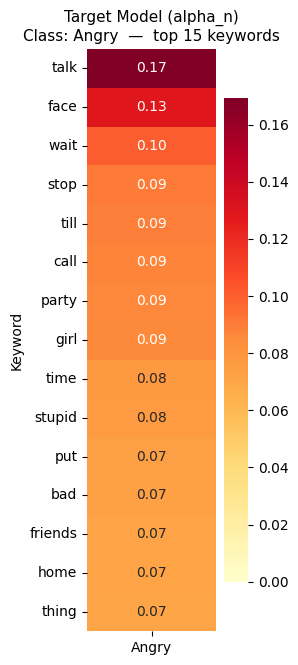

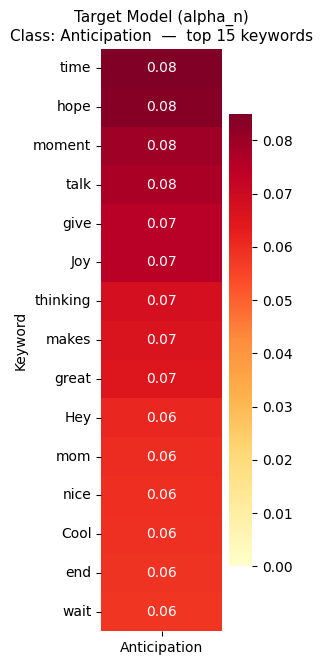

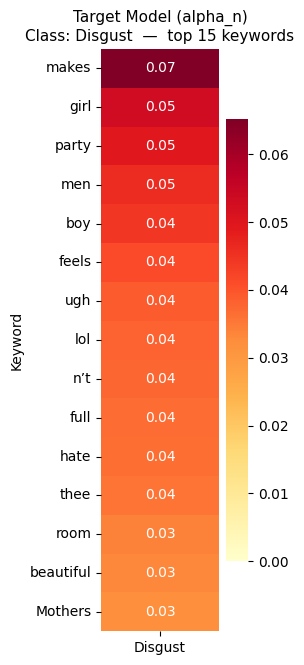

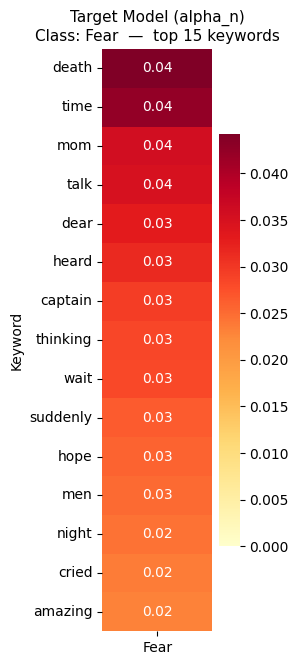

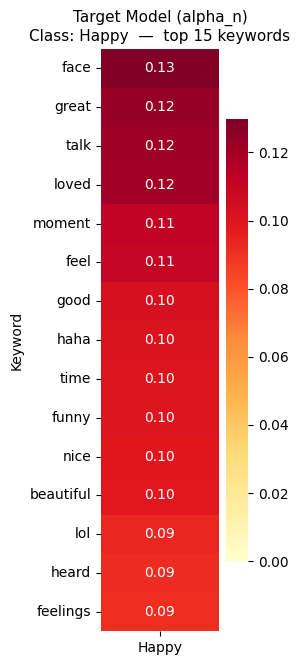

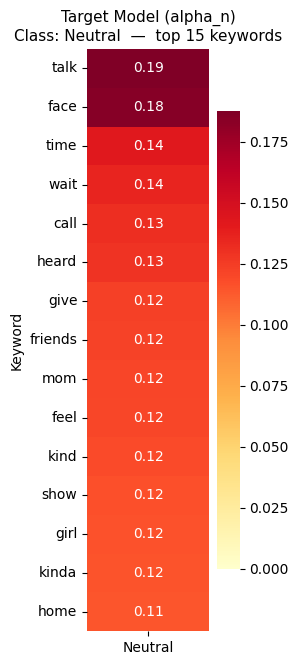

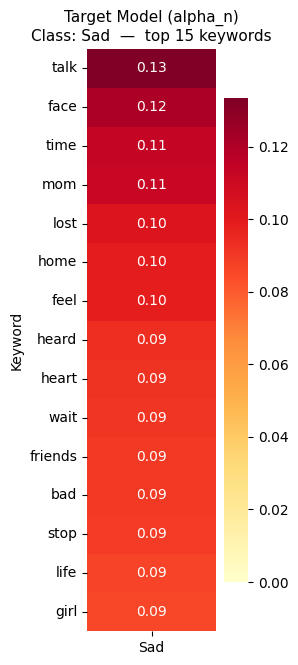

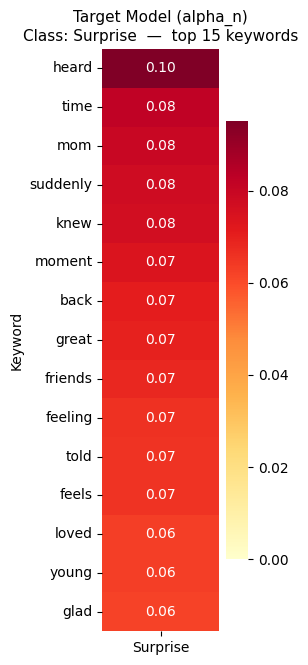

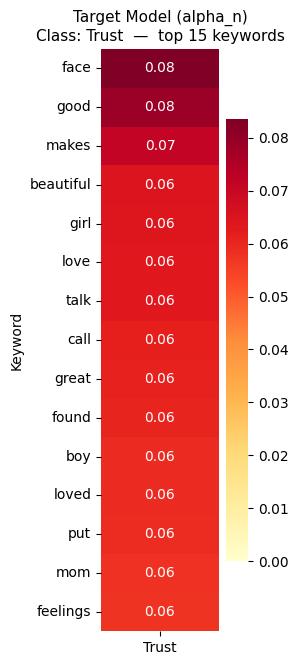

In [ ]:
if "alpha_n" in all_bee_results:
    visualize_bee_results(
        all_bee_results["alpha_n"]["bee_df"], ID2LABEL,
        title_prefix="Target Model (alpha_n)", top_k=15
    )
else:
    print("alpha_n results not available.")

## Visualize: Reference model BEE heatmaps

In [ ]:
if "reference" in all_bee_results:
    visualize_bee_results(
        all_bee_results["reference"]["bee_df"], ID2LABEL,
        title_prefix="Reference Model (frozen body)", top_k=15
    )
else:
    print("Reference model results not available.")

Reference model results not available.


## Align all BEE matrices to a union keyword vocabulary

In [ ]:
canonical_label_to_idx = {label: i for i, label in enumerate(CANONICAL_LABELS)}

# Build union of all keywords
all_keywords_set = set()
for result in all_bee_results.values():
    all_keywords_set.update(result["keywords"])
all_keywords_union = sorted(all_keywords_set)
keyword_to_idx     = {kw: i for i, kw in enumerate(all_keywords_union)}

num_keywords = len(all_keywords_union)
num_classes  = 9
print(f"Union vocabulary: {num_keywords} keywords across {num_classes} classes.")


def align_matrix(result):
    """
    Map a result's BEE DataFrame onto the global (num_keywords, 9) grid,
    zero-filling any missing keywords or label columns.
    """
    aligned  = np.zeros((num_keywords, num_classes))
    kw_list  = result["keywords"]
    bee_df   = result["bee_df"]
    present_labels = [col for col in bee_df.columns if col in canonical_label_to_idx]

    for local_idx, kw in enumerate(kw_list):
        global_idx = keyword_to_idx[kw]
        for label in present_labels:
            class_idx = canonical_label_to_idx[label]
            aligned[global_idx, class_idx] = bee_df.iloc[local_idx][label]
    return aligned


aligned_matrices = {}
for key, result in all_bee_results.items():
    aligned_matrices[key] = align_matrix(result)
    print(f"  Aligned {key}: {aligned_matrices[key].shape}")

print("\n✓ All matrices aligned.")

Union vocabulary: 535 keywords across 9 classes.
  Aligned alpha_n: (535, 9)
  Aligned n-1_no_EmoLit: (535, 9)
  Aligned n-1_no_Emotion20: (535, 9)
  Aligned n-1_no_GoEmotions: (535, 9)
  Aligned n-1_no_XED_SMED: (535, 9)
  Aligned single_EmoLit: (535, 9)
  Aligned single_Emotion20: (535, 9)
  Aligned single_GoEmotions: (535, 9)
  Aligned single_XED_SMED: (535, 9)

✓ All matrices aligned.


## Diagnostic Matrix: cos_sim(a_1, a_{n\\1})

In [ ]:
# a_{n\1,i}  =  alpha_n - alpha_{n-1,i}   (contribution of dataset i)
# a_{1,i}    =  alpha_{1,i}                 (fingerprint from dataset i alone)
# D[i,j]     =  cos_sim(a_{1,i}, a_{n\1,j})  — diagonal should dominate

alpha_n_matrix = aligned_matrices["alpha_n"]

a_n1 = {}
for name, n1_key in zip(DATASET_NAMES, N1_KEYS):
    diff = alpha_n_matrix - aligned_matrices[n1_key]
    a_n1[name] = diff.flatten()
    print(f"  a_n\\1 [{name}]: norm={np.linalg.norm(a_n1[name]):.4f}")

a_1 = {}
for name, s_key in zip(DATASET_NAMES, SINGLE_KEYS):
    a_1[name] = aligned_matrices[s_key].flatten()
    print(f"  a_1   [{name}]: norm={np.linalg.norm(a_1[name]):.4f}")

# Build 4x4 matrix
diagnostic_matrix = np.zeros((4, 4))
for i, name_i in enumerate(DATASET_NAMES):
    for j, name_j in enumerate(DATASET_NAMES):
        diagnostic_matrix[i, j] = sklearn_cosine_sim(
            a_1[name_i].reshape(1, -1), a_n1[name_j].reshape(1, -1)
        )[0, 0]

diag_df = pd.DataFrame(
    diagnostic_matrix,
    index  =[f"a_1({n})"    for n in DATASET_NAMES],
    columns=[f"a_n\\1({n})" for n in DATASET_NAMES],
)
print("\nDiagnostic Matrix:")
print(diag_df.to_string())
print(f"\nDiagonal: {np.diag(diagnostic_matrix)}")
for i, name in enumerate(DATASET_NAMES):
    row = diagnostic_matrix[i]
    dominant = all(row[i] >= row[j] for j in range(4) if j != i)
    print(f"  {name}: diag={row[i]:.4f}  dominant={'YES' if dominant else 'NO'}")

  a_n\1 [EmoLit]: norm=1.6243
  a_n\1 [Emotion20]: norm=1.1170
  a_n\1 [GoEmotions]: norm=1.0918
  a_n\1 [XED_SMED]: norm=1.2245
  a_1   [EmoLit]: norm=2.1744
  a_1   [Emotion20]: norm=2.6980
  a_1   [GoEmotions]: norm=1.7503
  a_1   [XED_SMED]: norm=1.8224

Diagnostic Matrix:
                 a_n\1(EmoLit)  a_n\1(Emotion20)  a_n\1(GoEmotions)  a_n\1(XED_SMED)
a_1(EmoLit)           0.382086         -0.015809          -0.240877         0.033503
a_1(Emotion20)       -0.028342          0.216940          -0.011356         0.248392
a_1(GoEmotions)       0.006730          0.100139           0.029202         0.263397
a_1(XED_SMED)        -0.055294          0.101226          -0.023799         0.315829

Diagonal: [0.38208629 0.21694019 0.02920204 0.31582921]
  EmoLit: diag=0.3821  dominant=YES
  Emotion20: diag=0.2169  dominant=NO
  GoEmotions: diag=0.0292  dominant=NO
  XED_SMED: diag=0.3158  dominant=YES


## Visualize Diagnostic Matrix

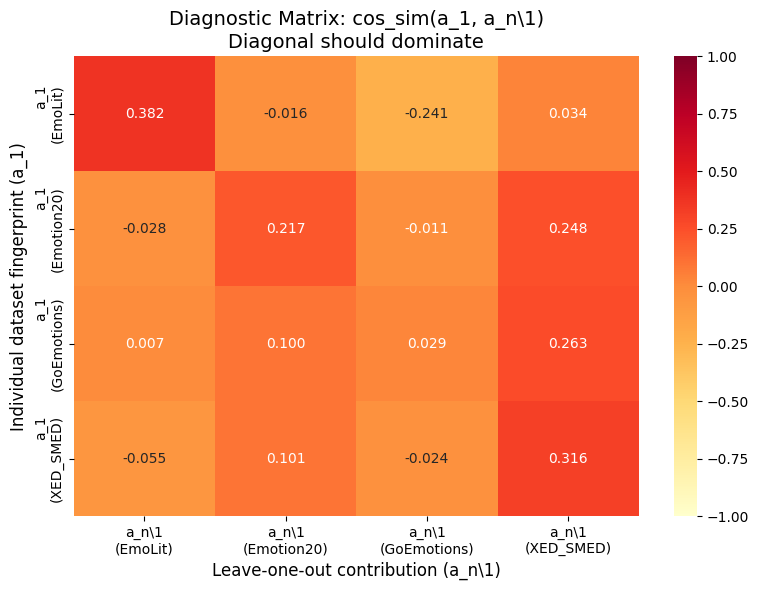

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    diagnostic_matrix, annot=True, fmt=".3f", cmap="YlOrRd",
    xticklabels=[f"a_n\\1\n({n})" for n in DATASET_NAMES],
    yticklabels=[f"a_1\n({n})"    for n in DATASET_NAMES],
    vmin=-1, vmax=1, center=0, ax=ax,
)
ax.set_title("Diagnostic Matrix: cos_sim(a_1, a_n\\1)\nDiagonal should dominate", fontsize=14)
ax.set_xlabel("Leave-one-out contribution (a_n\\1)", fontsize=12)
ax.set_ylabel("Individual dataset fingerprint (a_1)", fontsize=12)
plt.tight_layout()
plt.show()

## Class-Level Diagnostic (one 4×4 matrix per emotion)

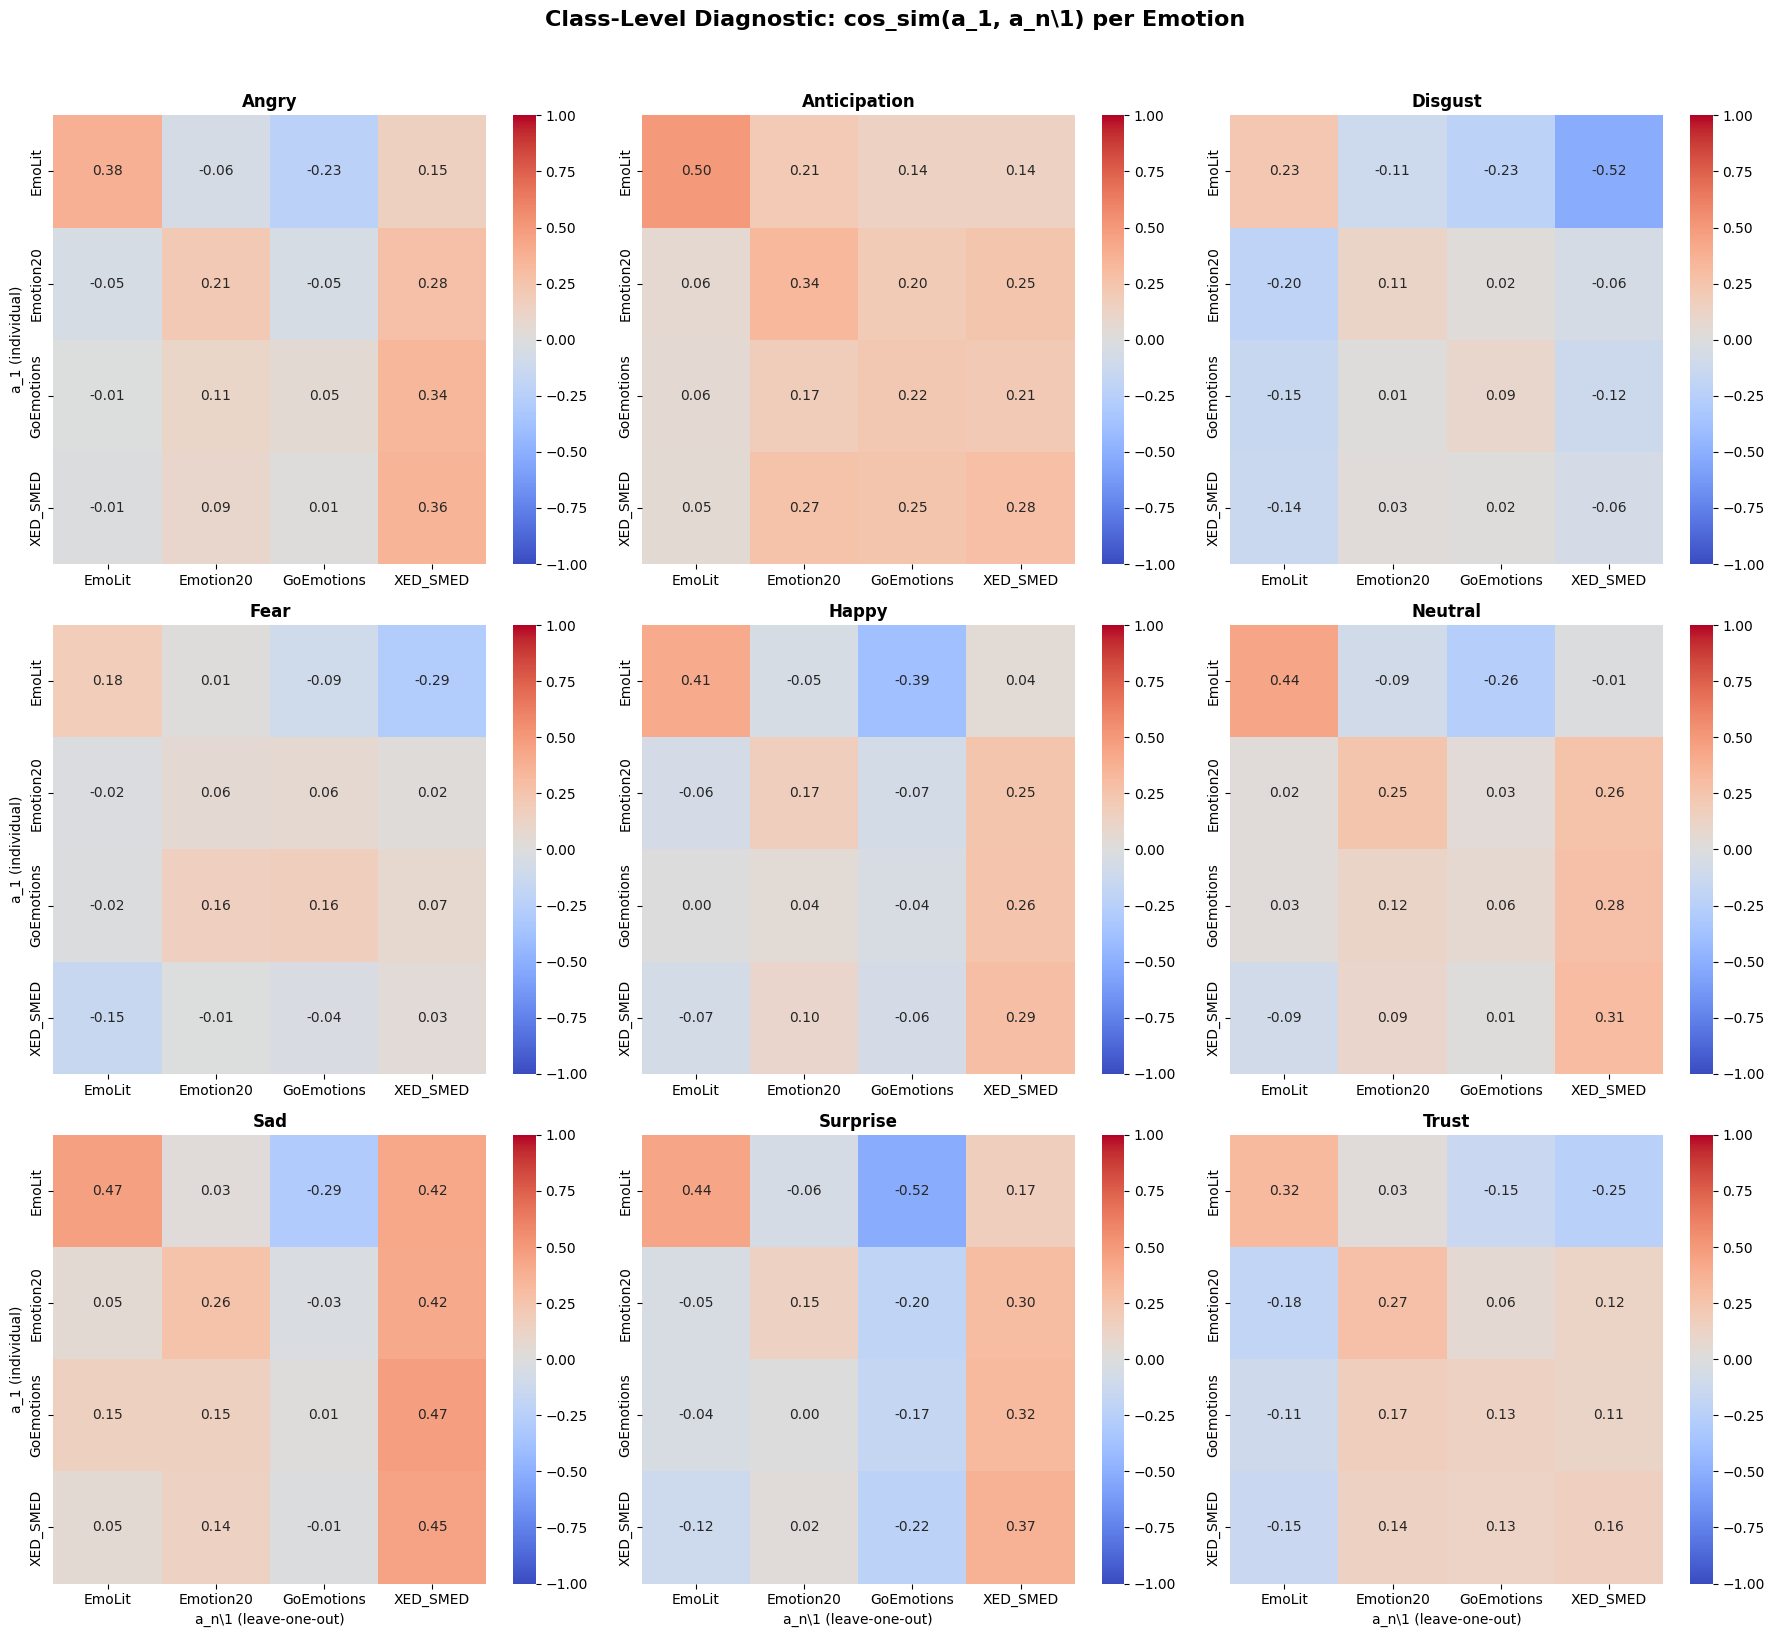

In [ ]:
class_diagnostics = {}
for class_idx, class_name in ID2LABEL.items():
    D_class = np.zeros((4, 4))
    for i, name_i in enumerate(DATASET_NAMES):
        for j, name_j in enumerate(DATASET_NAMES):
            vec_1  = aligned_matrices[SINGLE_KEYS[i]][:, class_idx].reshape(1, -1)
            vec_n1 = (alpha_n_matrix[:, class_idx] -
                      aligned_matrices[N1_KEYS[j]][:, class_idx]).reshape(1, -1)
            if np.linalg.norm(vec_1) < 1e-10 or np.linalg.norm(vec_n1) < 1e-10:
                D_class[i, j] = 0.0
            else:
                D_class[i, j] = sklearn_cosine_sim(vec_1, vec_n1)[0, 0]
    class_diagnostics[class_name] = D_class

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for idx, (class_name, D_class) in enumerate(class_diagnostics.items()):
    row, col = divmod(idx, 3)
    ax = axes[row][col]
    sns.heatmap(D_class, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1,
                xticklabels=DATASET_NAMES, yticklabels=DATASET_NAMES, ax=ax)
    ax.set_title(class_name, fontsize=12, fontweight='bold')
    ax.set_ylabel("a_1 (individual)"      if col == 0 else "", fontsize=10)
    ax.set_xlabel("a_n\\1 (leave-one-out)" if row == 2 else "", fontsize=10)
fig.suptitle("Class-Level Diagnostic: cos_sim(a_1, a_n\\1) per Emotion",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Class-Level Diagnostic: Pearson Correlation per Emotion

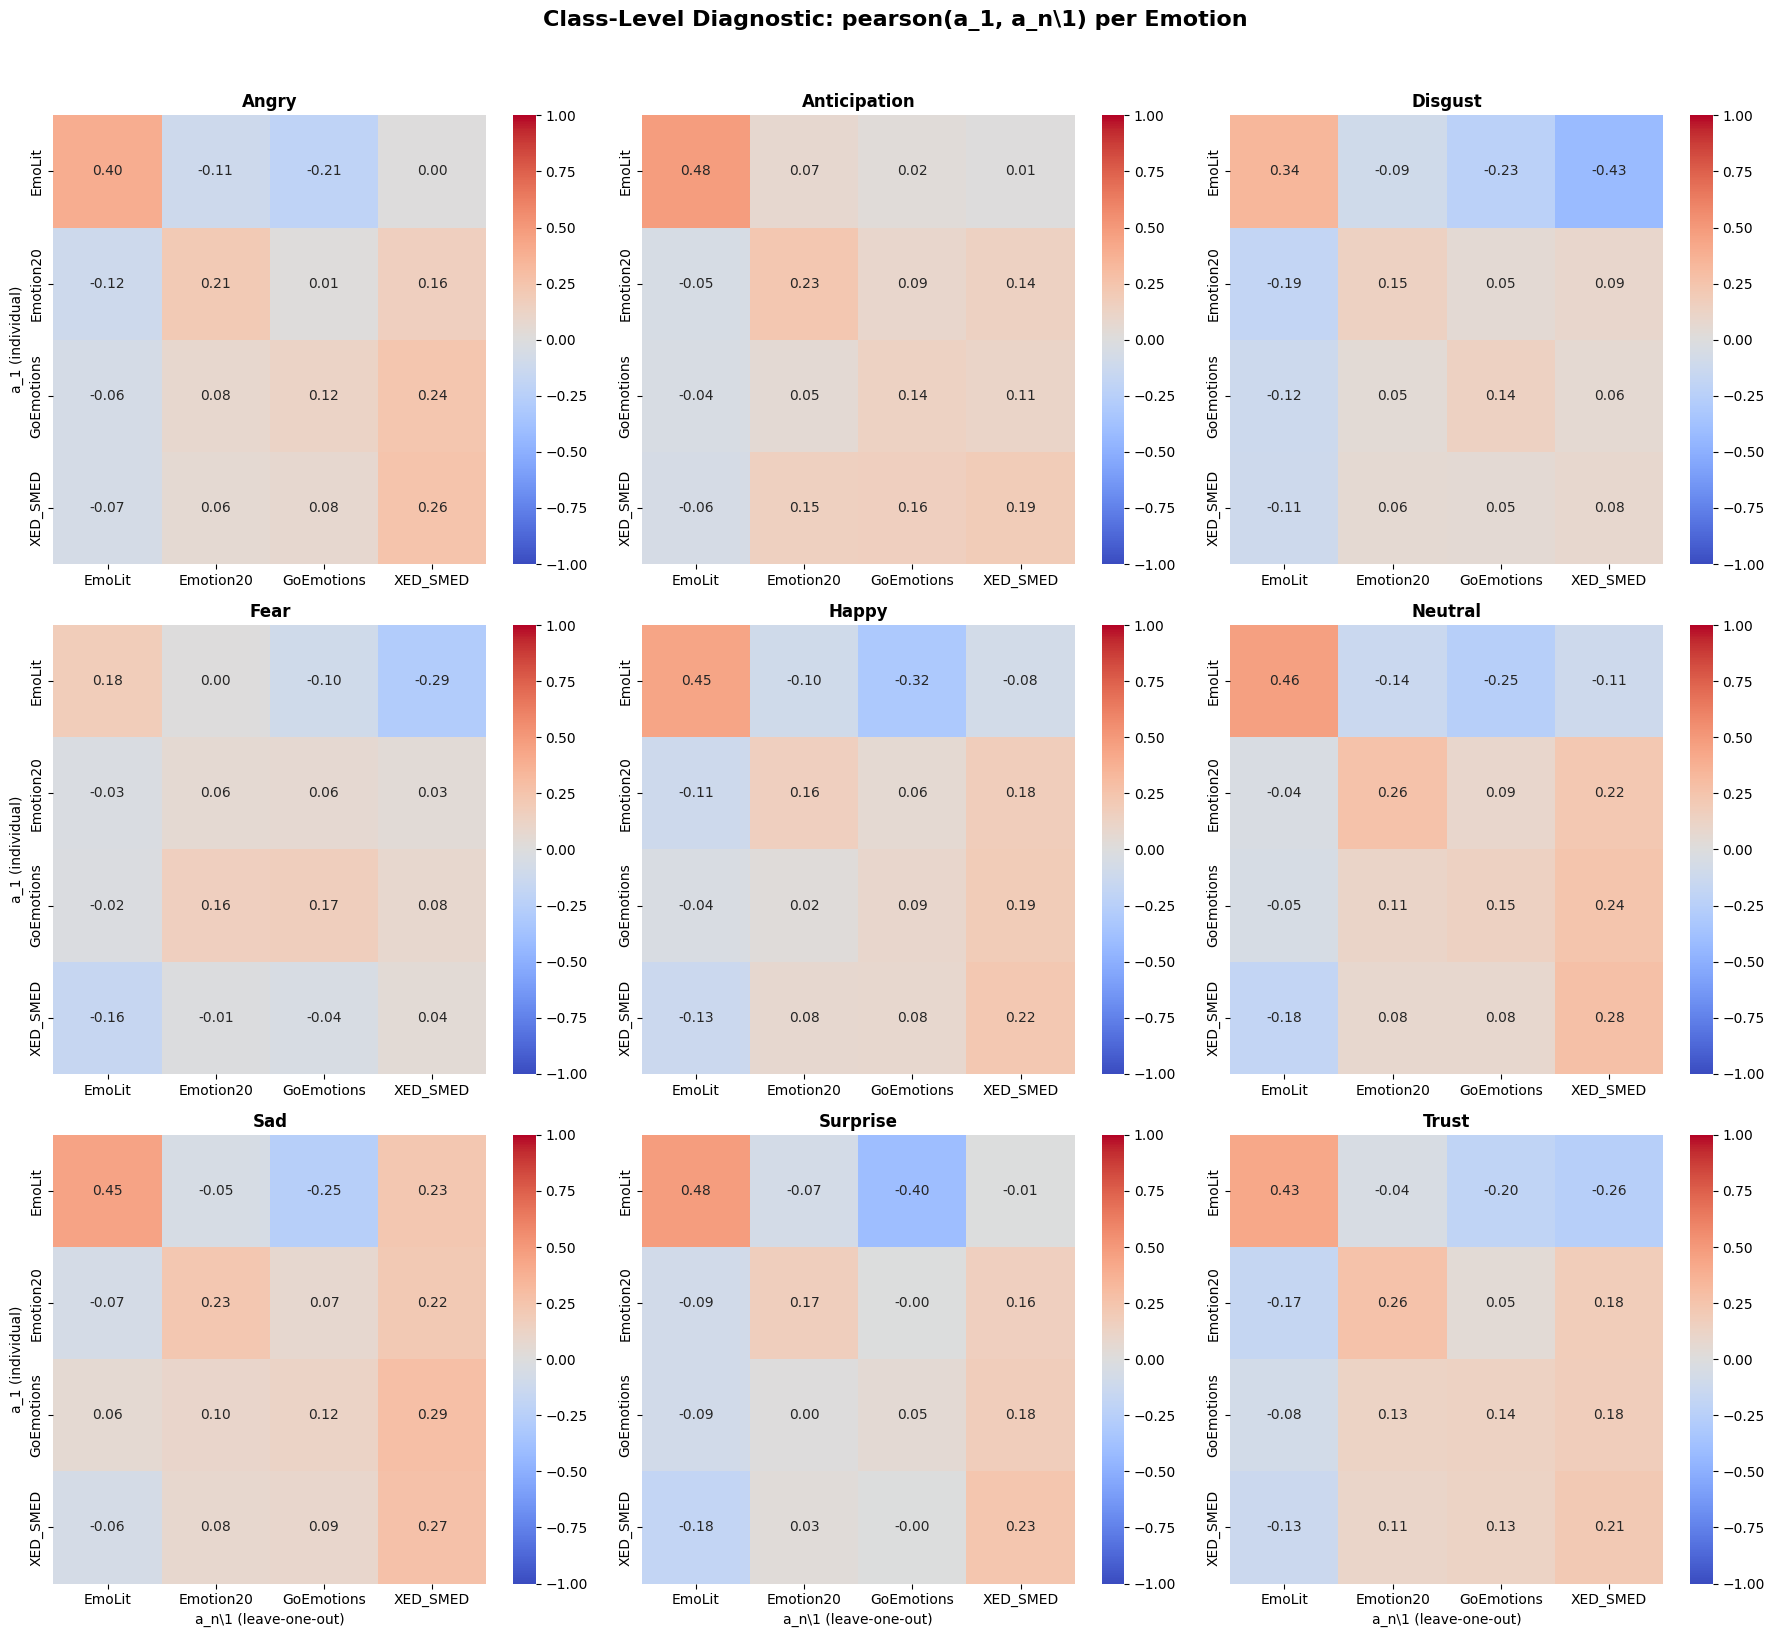

In [ ]:
from scipy.stats import pearsonr

# ── Class-Level Diagnostic: Pearson correlation(a_1, a_n\1) per Emotion ──

class_diagnostics_pearson = {}
for class_idx, class_name in ID2LABEL.items():
    D_class = np.zeros((4, 4))
    for i, name_i in enumerate(DATASET_NAMES):
        for j, name_j in enumerate(DATASET_NAMES):
            vec_1  = aligned_matrices[SINGLE_KEYS[i]][:, class_idx]
            vec_n1 = (alpha_n_matrix - aligned_matrices[N1_KEYS[j]])[:, class_idx]
            if np.std(vec_1) < 1e-10 or np.std(vec_n1) < 1e-10:
                D_class[i, j] = 0.0
            else:
                D_class[i, j], _ = pearsonr(vec_1, vec_n1)
    class_diagnostics_pearson[class_name] = D_class

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for idx, (class_name, D_class) in enumerate(class_diagnostics_pearson.items()):
    row, col = divmod(idx, 3)
    ax = axes[row][col]
    sns.heatmap(D_class, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1,
                xticklabels=DATASET_NAMES, yticklabels=DATASET_NAMES, ax=ax)
    ax.set_title(class_name, fontsize=12, fontweight='bold')
    ax.set_ylabel("a_1 (individual)"       if col == 0 else "", fontsize=10)
    ax.set_xlabel("a_n\\1 (leave-one-out)"  if row == 2 else "", fontsize=10)

# Hide unused subplot(s) if number of emotions is not a multiple of 3
for idx in range(len(class_diagnostics_pearson), axes.size):
    row, col = divmod(idx, 3)
    axes[row][col].set_visible(False)

fig.suptitle("Class-Level Diagnostic: pearson(a_1, a_n\\1) per Emotion",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Summary: Diagonal Dominance per Class

In [ ]:
print(f"{'CLASS':<15} | {'DIAG MEAN':>10} | {'OFF-DIAG MEAN':>14} | {'DOMINANT?':>10}")
print("-" * 60)
for class_name, D_class in class_diagnostics.items():
    diag_vals     = np.diag(D_class)
    mask          = ~np.eye(4, dtype=bool)
    off_diag_mean = D_class[mask].mean()
    diag_mean     = diag_vals.mean()
    print(f"{class_name:<15} | {diag_mean:>10.4f} | {off_diag_mean:>14.4f} | "
          f"{'YES' if diag_mean > off_diag_mean else 'NO':>10}")

print("\n" + "="*60)
print("GLOBAL:")
d = np.diag(diagnostic_matrix)
m = diagnostic_matrix[~np.eye(4, dtype=bool)]
print(f"  Diagonal mean:     {d.mean():.4f}")
print(f"  Off-diagonal mean: {m.mean():.4f}")
print(f"  Diagonal dominant: {'YES' if d.mean() > m.mean() else 'NO'}")

CLASS           |  DIAG MEAN |  OFF-DIAG MEAN |  DOMINANT?
------------------------------------------------------------
Angry           |     0.2485 |         0.0477 |        YES
Anticipation    |     0.3354 |         0.1665 |        YES
Disgust         |     0.0924 |        -0.1201 |        YES
Fear            |     0.1091 |        -0.0238 |        YES
Happy           |     0.2064 |        -0.0018 |        YES
Neutral         |     0.2648 |         0.0332 |        YES
Sad             |     0.2995 |         0.1294 |        YES
Surprise        |     0.1978 |        -0.0326 |        YES
Trust           |     0.2211 |        -0.0062 |        YES

GLOBAL:
  Diagonal mean:     0.2360
  Off-diagonal mean: 0.0315
  Diagonal dominant: YES


## Paired BEE Heatmaps: N-1 contribution vs Single fingerprint





Plot keywords (15): ['Amazing', 'Change', 'Check', 'English', 'German', 'Indian', 'Joy', 'Lmao', 'Ugh', 'Wow', 'art', 'beautiful', 'bit', 'body', 'call']


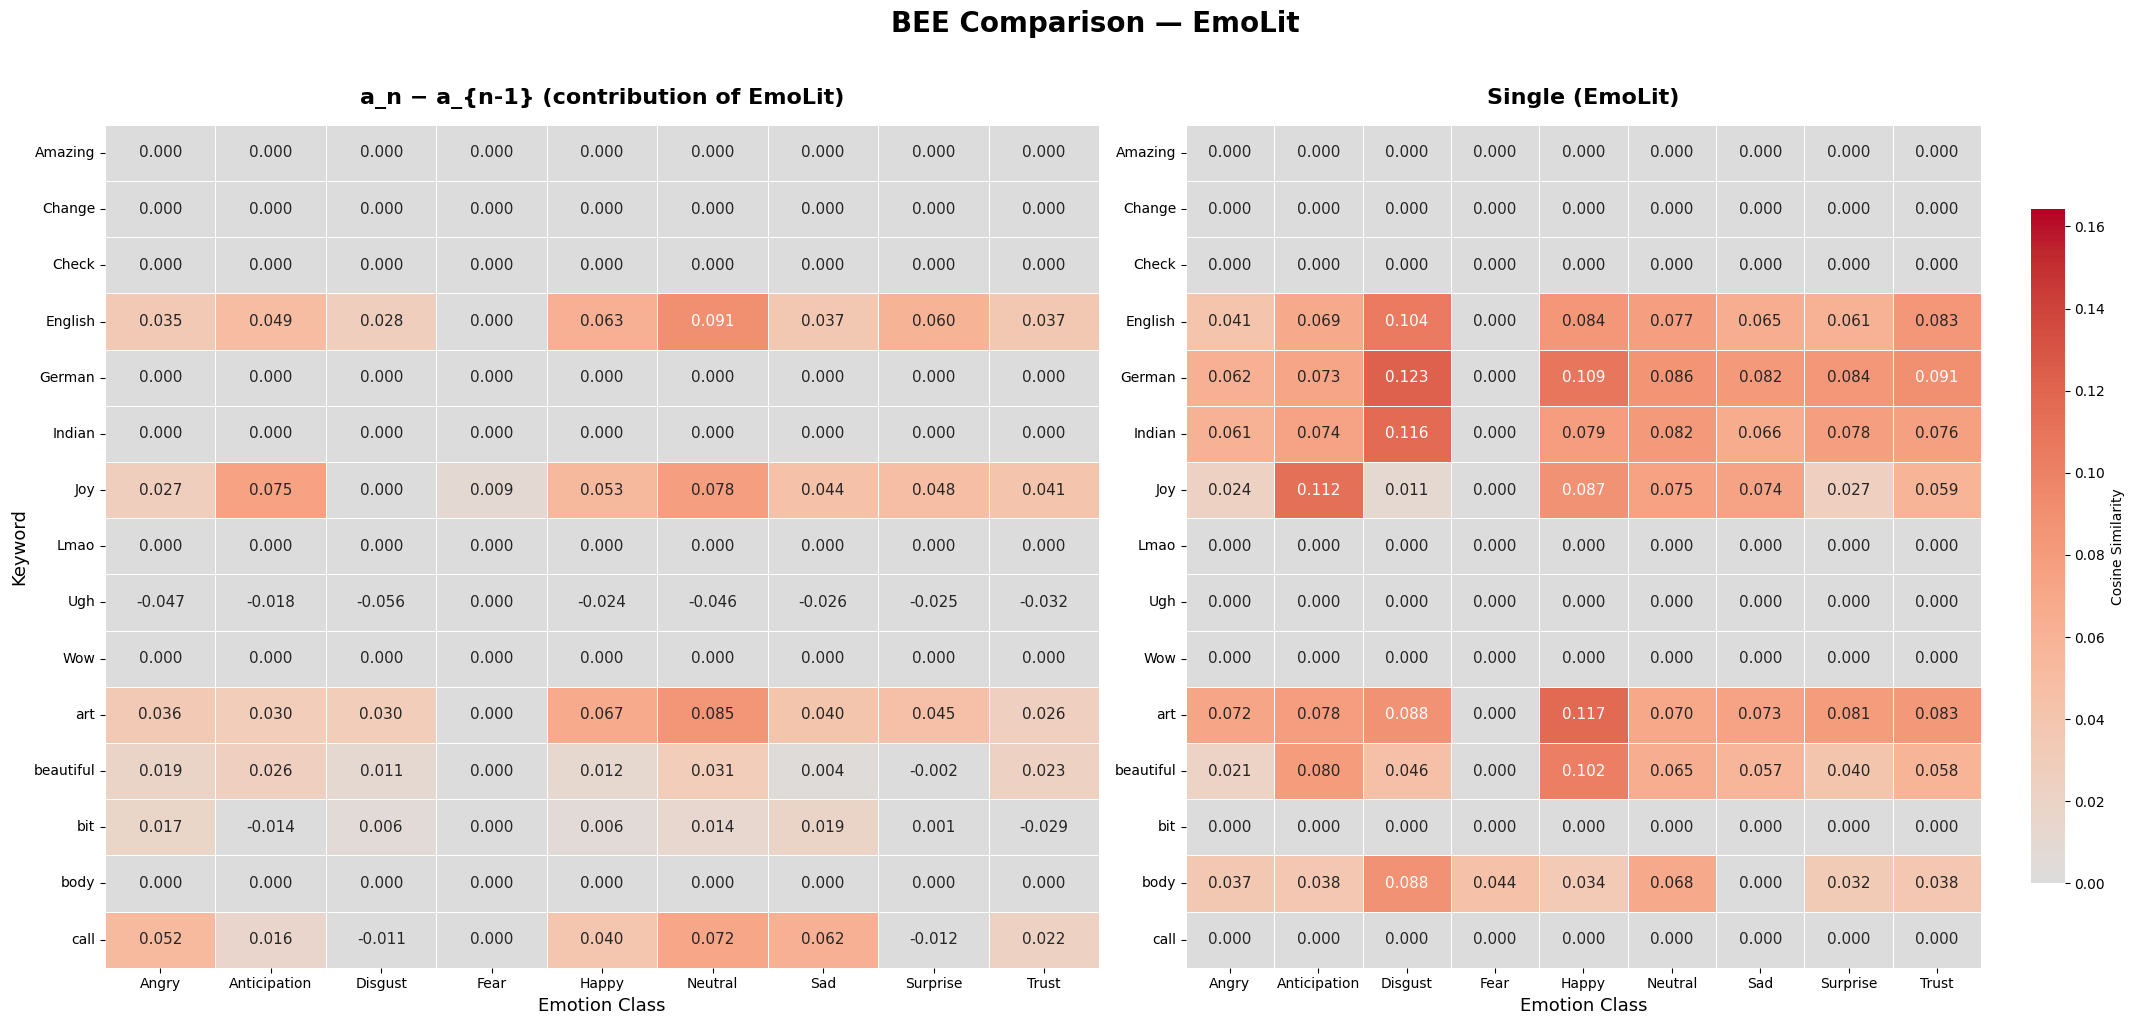

Saved: BEE_paired_EmoLit.png


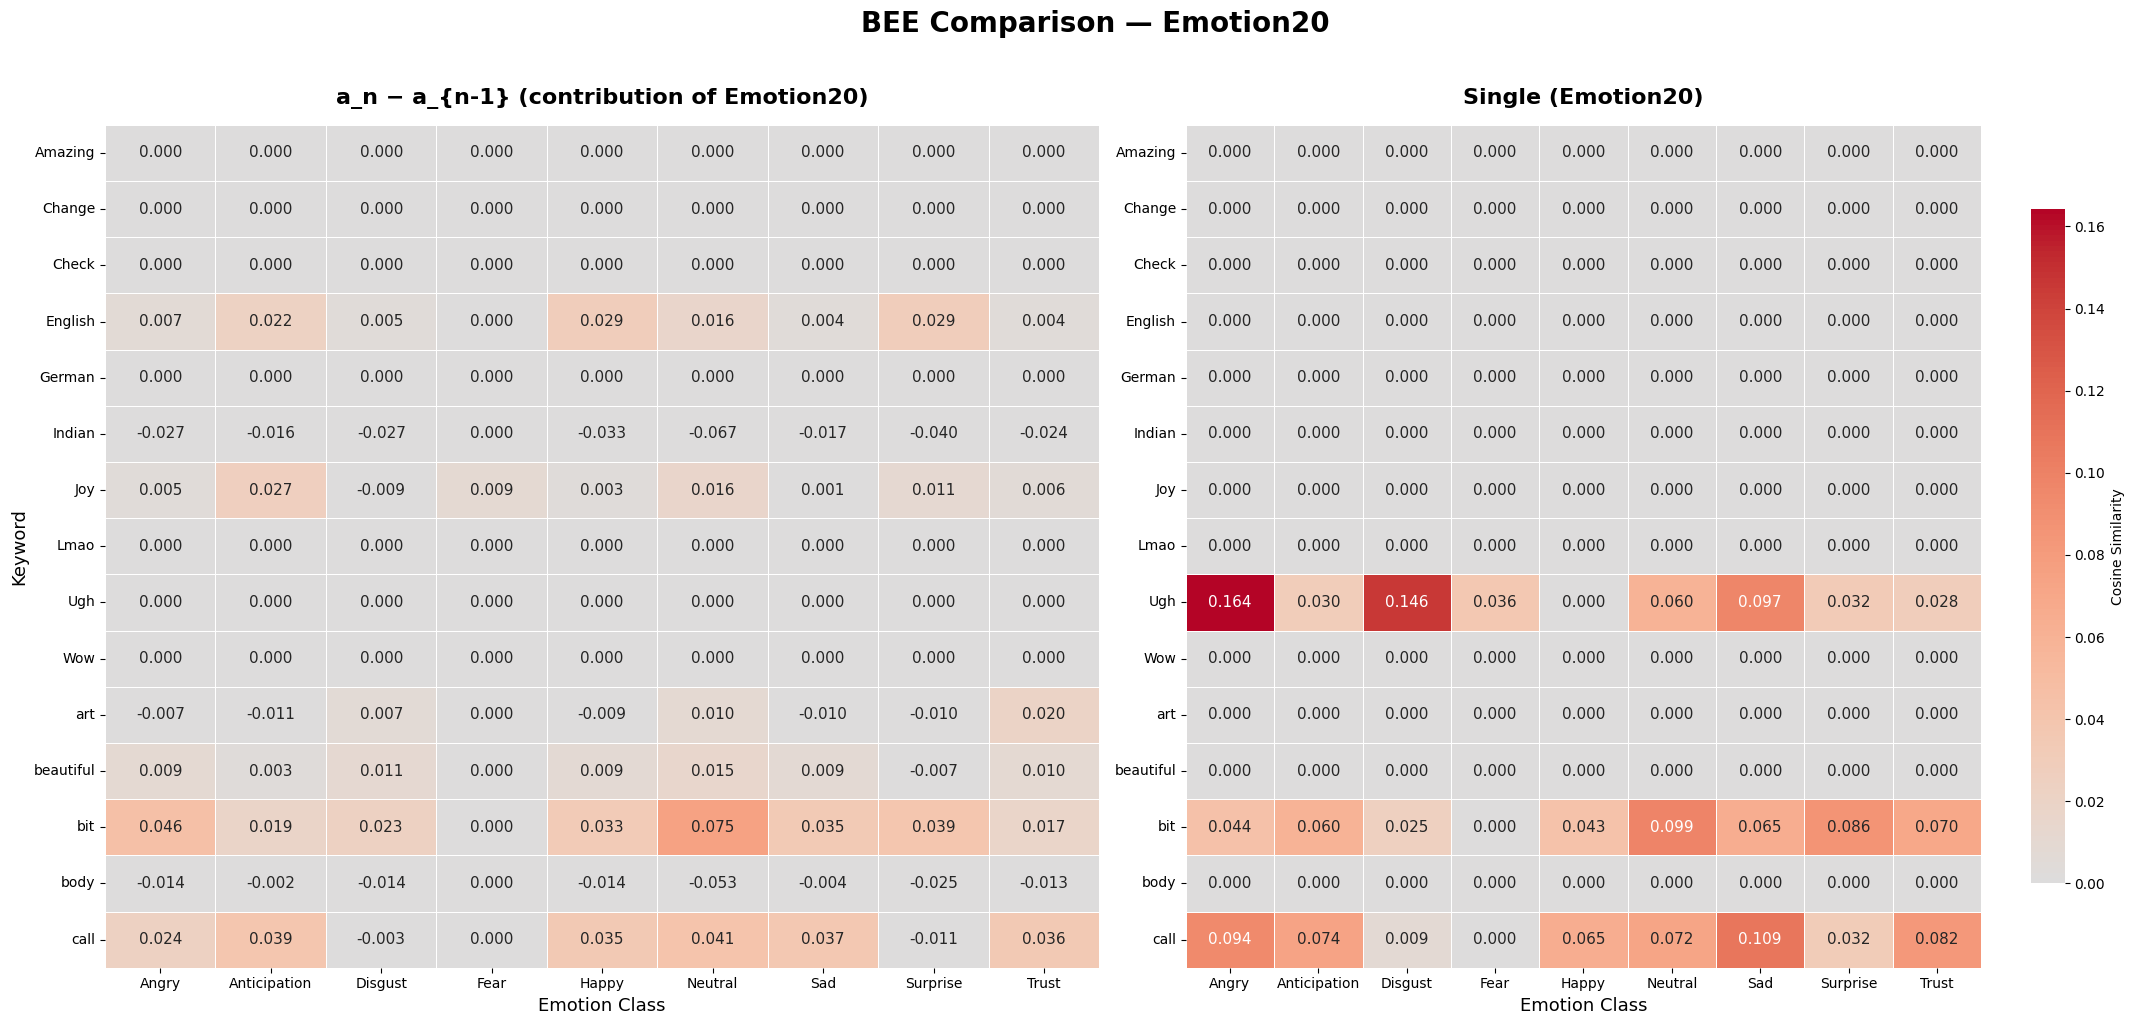

Saved: BEE_paired_Emotion20.png


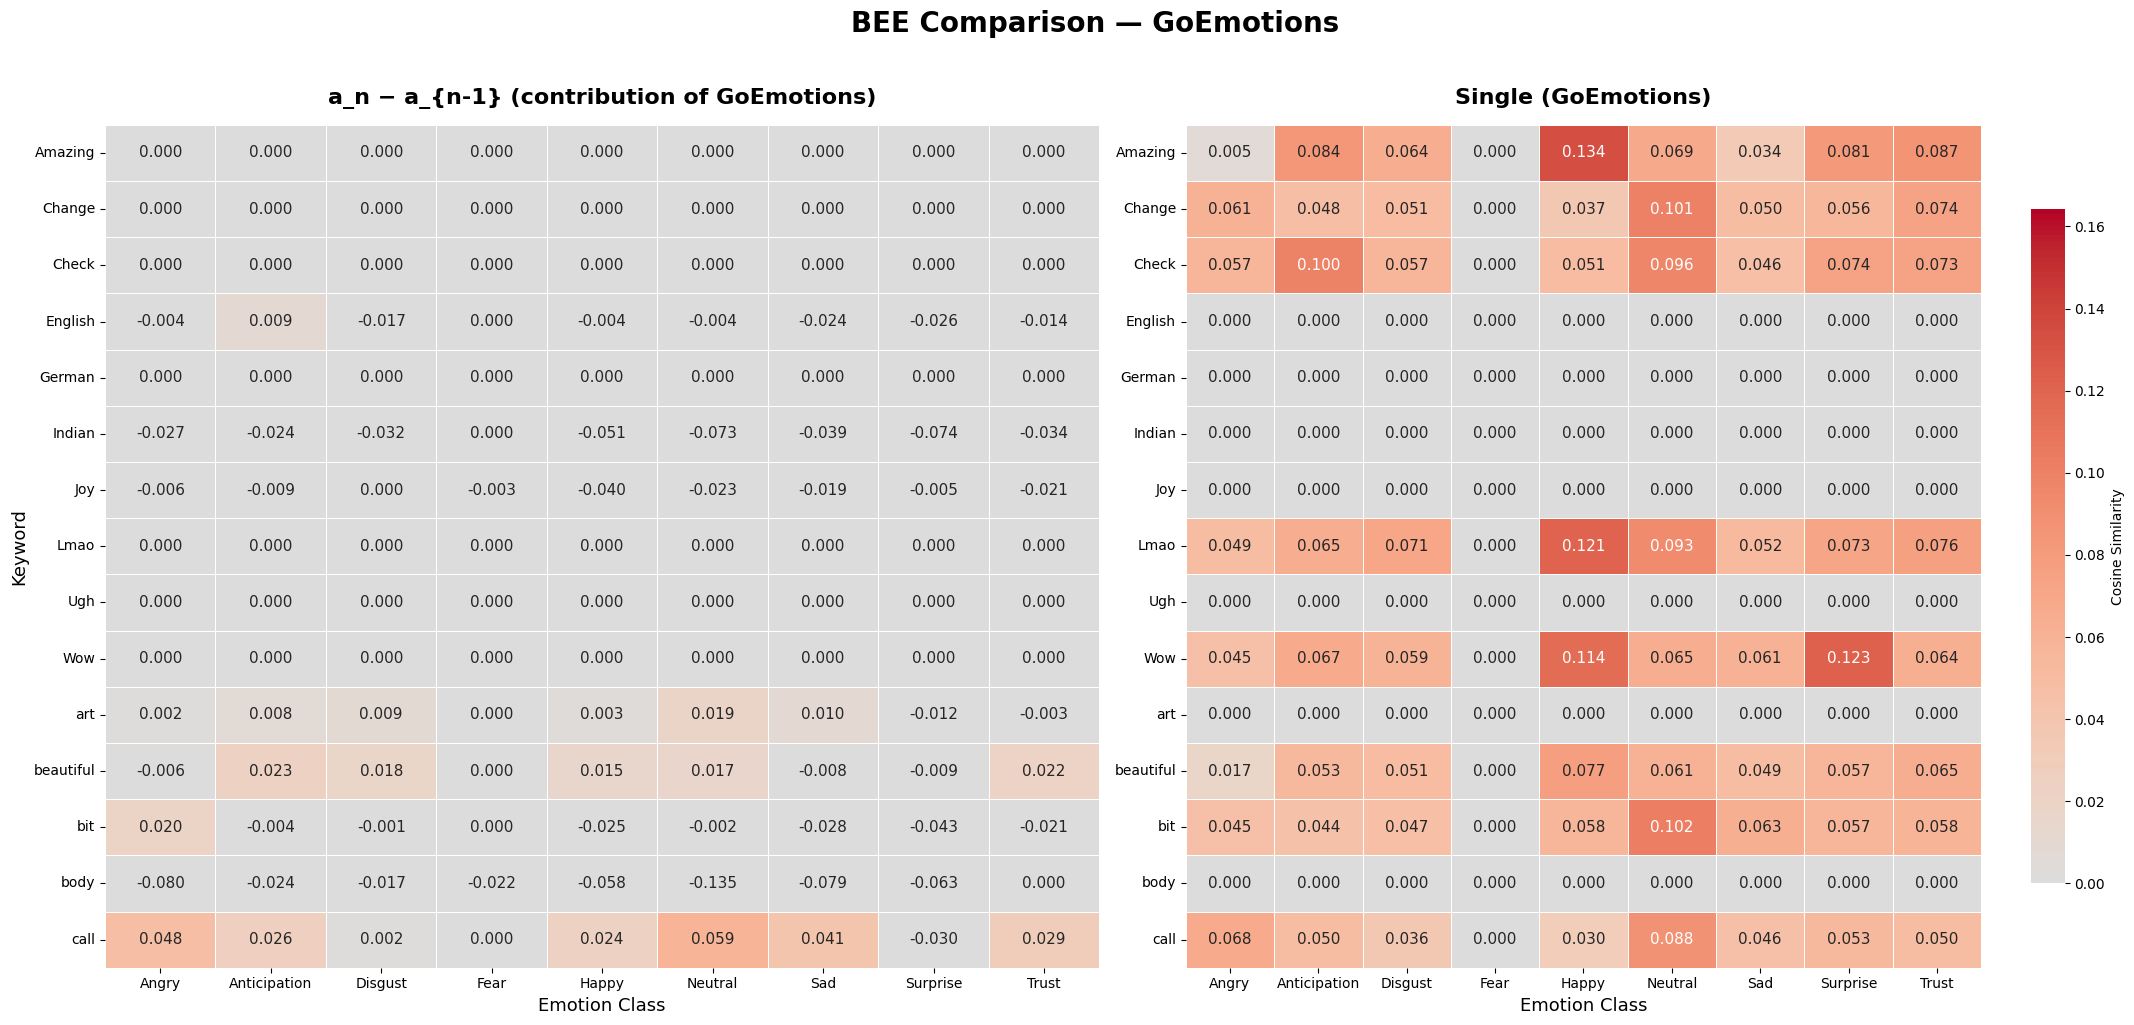

Saved: BEE_paired_GoEmotions.png


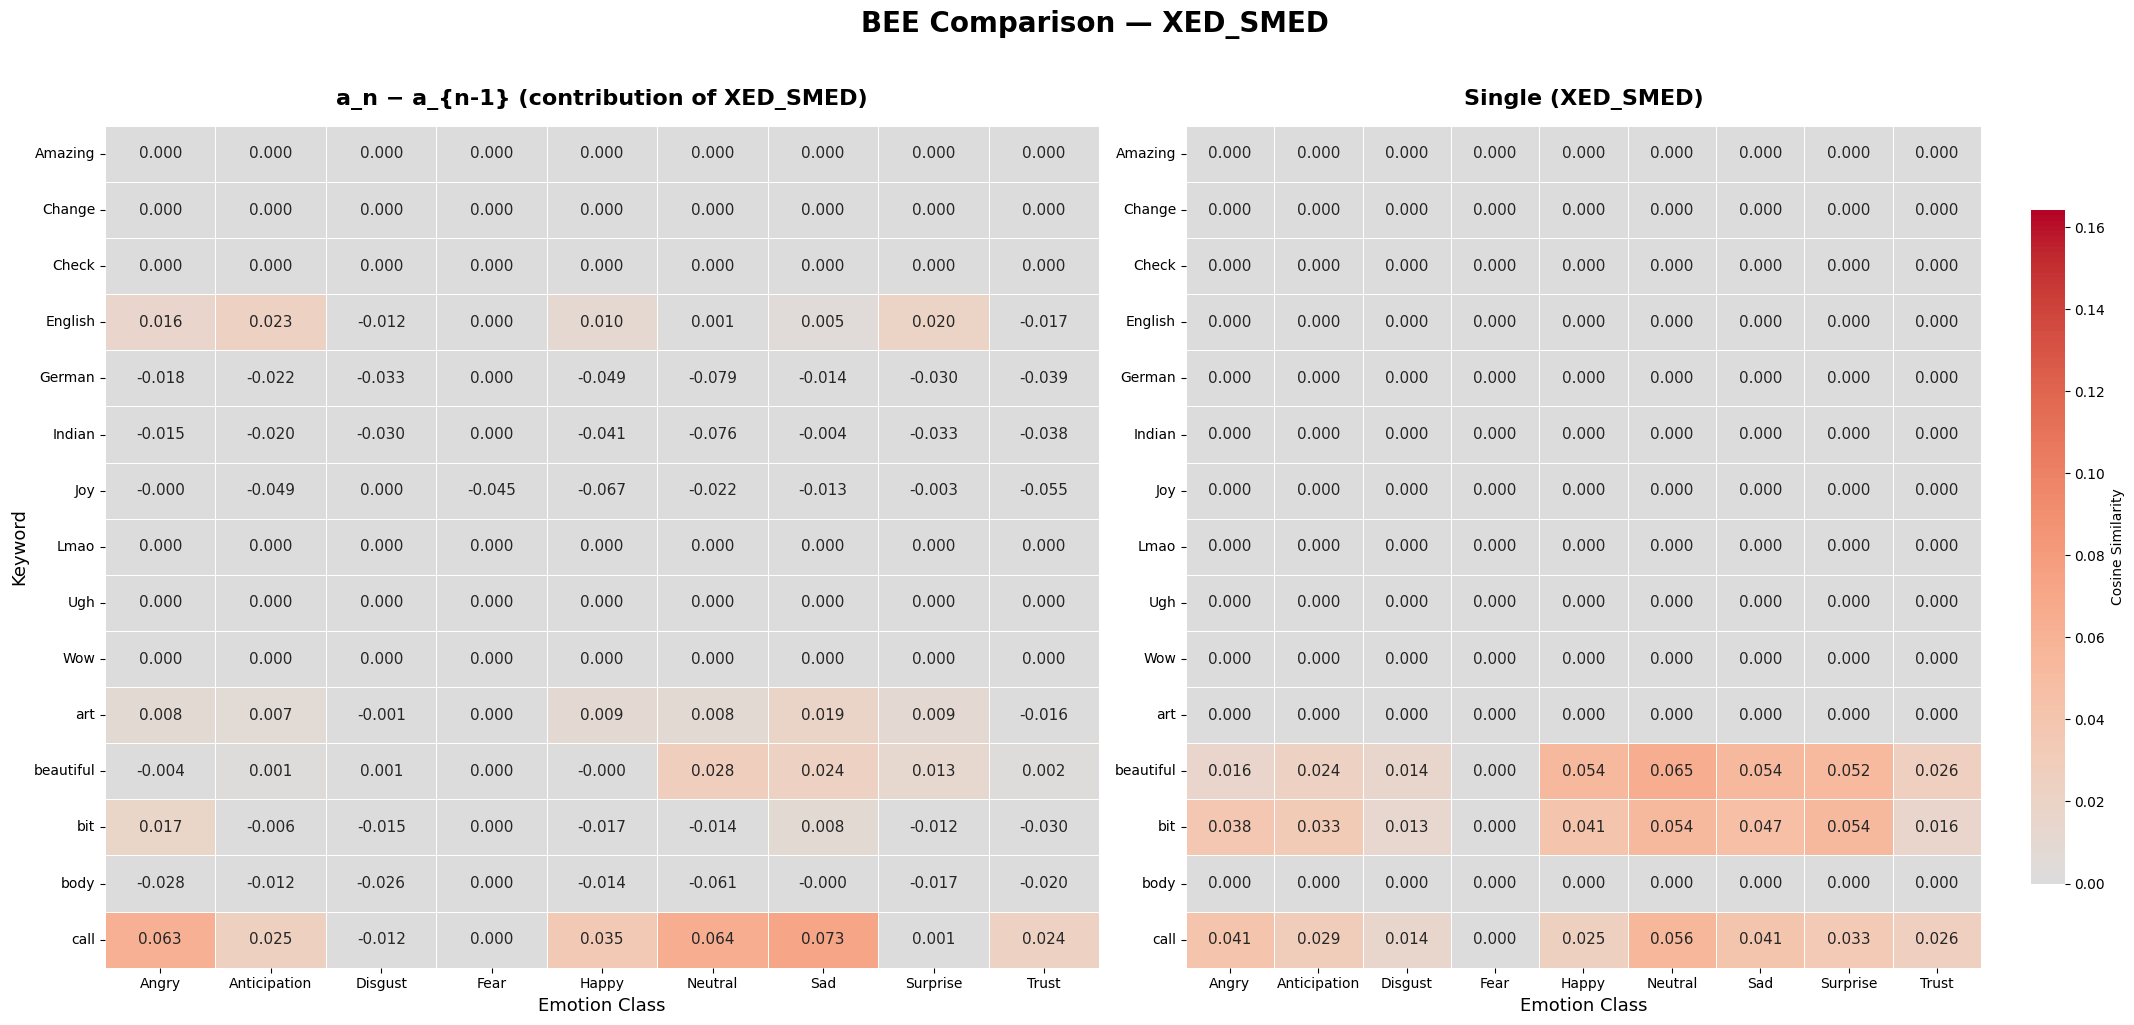

Saved: BEE_paired_XED_SMED.png


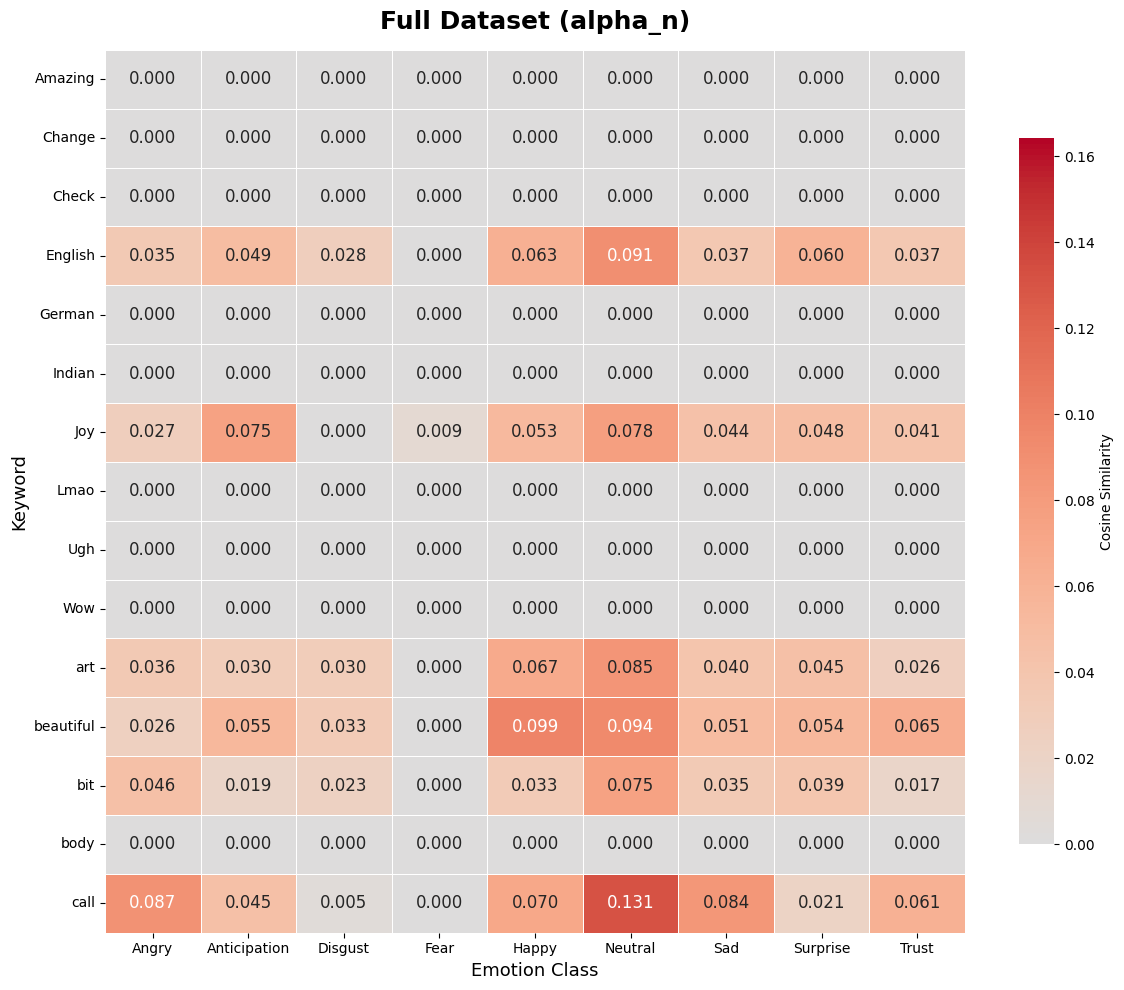

Saved: BEE_alpha_n_reference.png


In [ ]:
# Top 15 keywords by BEE score, taken from the union across all classifiers
top_keywords_set = set()
for config_key in ["alpha_n"] + N1_KEYS + SINGLE_KEYS:
    if config_key not in aligned_matrices:
        continue
    matrix = aligned_matrices[config_key]
    bias_scores = np.max(matrix, axis=1) - np.min(matrix, axis=1)
    top_indices = np.argsort(bias_scores)[::-1][:15]
    for idx in top_indices:
        top_keywords_set.add(all_keywords_union[idx])

plot_keywords  = sorted(top_keywords_set)[:15]
plot_kw_indices = [all_keywords_union.index(kw) for kw in plot_keywords]
print(f"Plot keywords ({len(plot_keywords)}): {plot_keywords}")

# Global color scale
all_vals = []
for config_key in ["alpha_n"] + N1_KEYS + SINGLE_KEYS:
    if config_key in aligned_matrices:
        all_vals.extend(aligned_matrices[config_key][plot_kw_indices].flatten())
vmin_global, vmax_global = min(all_vals), max(all_vals)

for ds_idx, ds_name in enumerate(DATASET_NAMES):
    n1_key     = N1_KEYS[ds_idx]
    single_key = SINGLE_KEYS[ds_idx]
    if n1_key not in aligned_matrices or single_key not in aligned_matrices:
        print(f"Skipping {ds_name} (missing results)")
        continue

    n1_matrix     = (aligned_matrices["alpha_n"] - aligned_matrices[n1_key])[plot_kw_indices]
    single_matrix = aligned_matrices[single_key][plot_kw_indices]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10), sharey=False)

    sns.heatmap(n1_matrix, annot=True, fmt=".3f", annot_kws={"size": 11},
                cmap="coolwarm", center=0, vmin=vmin_global, vmax=vmax_global,
                xticklabels=CANONICAL_LABELS, yticklabels=plot_keywords,
                ax=ax1, linewidths=0.5, linecolor="white", cbar=False)
    ax1.set_title(f"a_n − a_{{n-1}} (contribution of {ds_name})", fontsize=16, fontweight="bold", pad=15)
    ax1.set_xlabel("Emotion Class", fontsize=13); ax1.set_ylabel("Keyword", fontsize=13)

    sns.heatmap(single_matrix, annot=True, fmt=".3f", annot_kws={"size": 11},
                cmap="coolwarm", center=0, vmin=vmin_global, vmax=vmax_global,
                xticklabels=CANONICAL_LABELS, yticklabels=plot_keywords,
                ax=ax2, linewidths=0.5, linecolor="white",
                cbar_kws={"shrink": 0.8, "label": "Cosine Similarity"})
    ax2.set_title(f"Single ({ds_name})", fontsize=16, fontweight="bold", pad=15)
    ax2.set_xlabel("Emotion Class", fontsize=13)

    fig.suptitle(f"BEE Comparison — {ds_name}", fontsize=20, fontweight="bold", y=1.02)
    plt.tight_layout()
    fname = f"BEE_paired_{ds_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# alpha_n reference
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(aligned_matrices["alpha_n"][plot_kw_indices], annot=True, fmt=".3f",
            annot_kws={"size": 12}, cmap="coolwarm", center=0,
            vmin=vmin_global, vmax=vmax_global,
            xticklabels=CANONICAL_LABELS, yticklabels=plot_keywords, ax=ax,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "Cosine Similarity"})
ax.set_title("Full Dataset (alpha_n)", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Emotion Class", fontsize=13); ax.set_ylabel("Keyword", fontsize=13)
plt.tight_layout()
plt.savefig("BEE_alpha_n_reference.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: BEE_alpha_n_reference.png")

## Export to Excel (colored, all classifiers)

In [ ]:
import openpyxl
from openpyxl.styles import PatternFill, Font, Border, Side
from openpyxl.utils import get_column_letter

def value_to_coolwarm_hex(val, vmin, vmax):
    if vmax == vmin: return "FFFFFF"
    t = (val - vmin) / (vmax - vmin)
    if t < 0.5:
        t2 = t * 2
        r = int(59  + (255 - 59)  * t2)
        g = int(76  + (255 - 76)  * t2)
        b = int(192 + (255 - 192) * t2)
    else:
        t2 = (t - 0.5) * 2
        r, g, b = 255, int(255 * (1 - t2)), int(255 * (1 - t2))
    return f"{min(255,max(0,r)):02X}{min(255,max(0,g)):02X}{min(255,max(0,b)):02X}"

def value_to_ylorrd_hex(val, vmin, vmax):
    if vmax == vmin: return "FFFFB2"
    t = (val - vmin) / (vmax - vmin)
    return f"FF{int(255*(1-t*0.7)):02X}{int(178*(1-t)):02X}"

all_config_keys_ordered   = ["alpha_n"] + N1_KEYS + SINGLE_KEYS
all_config_names_ordered  = ["Full (alpha_n)"] +     [f"N-1 No {n}" for n in DATASET_NAMES] +     [f"Single {n}" for n in DATASET_NAMES]

# Build aligned DataFrames
all_dfs = {}
for config_key, config_name in zip(all_config_keys_ordered, all_config_names_ordered):
    if config_key not in aligned_matrices:
        continue
    matrix = aligned_matrices[config_key]
    bias   = np.max(matrix, axis=1) - np.min(matrix, axis=1)
    df     = pd.DataFrame({"Keyword": all_keywords_union, "Bias_Score": bias})
    for ci, label in enumerate(CANONICAL_LABELS):
        df[label] = matrix[:, ci]
    df = df.sort_values("Keyword").reset_index(drop=True)
    all_dfs[config_name] = df

# Global scale
all_class_vals = [v for df in all_dfs.values() for v in df[CANONICAL_LABELS].values.flatten()]
all_bias_vals  = [v for df in all_dfs.values() for v in df["Bias_Score"].values]
cmin, cmax = min(all_class_vals), max(all_class_vals)
bmin, bmax = min(all_bias_vals),  max(all_bias_vals)

hdr_font   = Font(bold=True, size=11)
thin       = Border(*[Side(style="thin")]*4)

wb = openpyxl.Workbook()
wb.remove(wb.active)

for config_name, df in all_dfs.items():
    ws   = wb.create_sheet(title=config_name[:31])
    cols = list(df.columns)
    for ci, cn in enumerate(cols, 1):
        cell = ws.cell(1, ci, cn); cell.font = hdr_font; cell.border = thin
        cell.fill = PatternFill(start_color="D9E1F2", end_color="D9E1F2", fill_type="solid")
    for ri, (_, row) in enumerate(df.iterrows(), 2):
        for ci, cn in enumerate(cols, 1):
            val  = row[cn]
            cell = ws.cell(ri, ci, val); cell.border = thin
            if cn in CANONICAL_LABELS:
                cell.number_format = "0.0000"
                c = value_to_coolwarm_hex(val, cmin, cmax)
                cell.fill = PatternFill(start_color=c, end_color=c, fill_type="solid")
            elif cn == "Bias_Score":
                cell.number_format = "0.0000"
                c = value_to_ylorrd_hex(val, bmin, bmax)
                cell.fill = PatternFill(start_color=c, end_color=c, fill_type="solid")
    ws.column_dimensions["A"].width = 20
    for ci in range(2, len(cols)+1):
        ws.column_dimensions[get_column_letter(ci)].width = 14

excel_path = "/content/BEE_all_classifiers.xlsx"
wb.save(excel_path)
print(f"Saved: {excel_path}")

from google.colab import files
files.download(excel_path)

Saved: /content/BEE_all_classifiers.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Print Top Keywords per Emotion (Target Model)

In [ ]:
if "alpha_n" in all_bee_results:
    bee_df = all_bee_results["alpha_n"]["bee_df"]
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', None)
    for label in LABEL_NAMES:
        print(f"\n=== Top Keywords for: {label} (Target Model) ===")
        top = bee_df.sort_values(by=label, ascending=False)
        print(top[['Keyword', label]].head(20).to_string(index=False))


=== Top Keywords for: Angry (Target Model) ===
Keyword    Angry
   talk 0.169139
   face 0.129355
   wait 0.100686
   stop 0.090761
   till 0.089845
   call 0.087232
  party 0.085965
   girl 0.085854
   time 0.077562
 stupid 0.077297
    put 0.074100
    bad 0.072744
friends 0.071864
   home 0.071488
  thing 0.070186
   show 0.068978
   knew 0.068611
   kind 0.066184
 coming 0.065904
  feels 0.065856

=== Top Keywords for: Anticipation (Target Model) ===
 Keyword  Anticipation
    time      0.084978
    hope      0.083973
  moment      0.079625
    talk      0.077541
    give      0.074987
     Joy      0.074894
thinking      0.068233
   makes      0.066129
   great      0.065088
     Hey      0.061138
     mom      0.059965
    nice      0.059642
    Cool      0.059370
     end      0.058423
    wait      0.058243
    knew      0.058233
    love      0.056512
    good      0.056338
  coming      0.056313
 tonight      0.055452

=== Top Keywords for: Disgust (Target Model) ===
  Keywo

YAKE keyword overlap: N-1 (rows) vs Single (columns)
            EmoLit  Emotion20  GoEmotions  XED_SMED
EmoLit          58        118         122       133
Emotion20      153         54          86        90
GoEmotions     149         74          83        90
XED_SMED       158         70          81        81


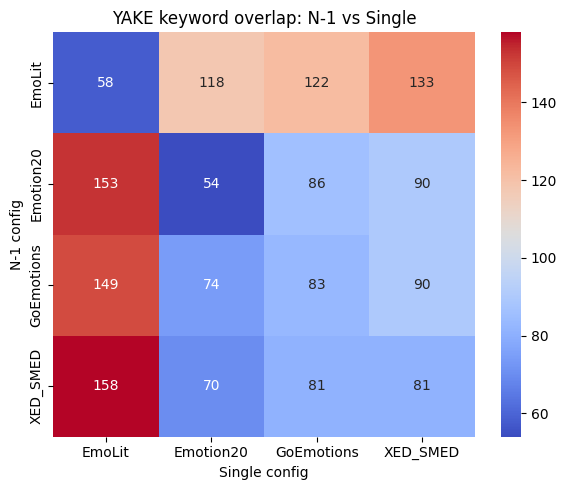

In [ ]:
# ============================================================================
# Keyword overlap matrix: N-1 vs Single (YAKE keywords)
# ============================================================================

overlap_matrix = np.zeros((len(N1_KEYS), len(SINGLE_KEYS)), dtype=int)

for i, n1_key in enumerate(N1_KEYS):
    kws_n1 = set(per_config_keywords[n1_key])
    for j, s1_key in enumerate(SINGLE_KEYS):
        kws_s1 = set(per_config_keywords[s1_key])
        overlap_matrix[i, j] = len(kws_n1 & kws_s1)

overlap_df = pd.DataFrame(
    overlap_matrix,
    index=[k.replace("n-1_no_", "") for k in N1_KEYS],
    columns=[k.replace("single_", "") for k in SINGLE_KEYS],
)

print("YAKE keyword overlap: N-1 (rows) vs Single (columns)")
print(overlap_df)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(overlap_df, annot=True, fmt="d", cmap="coolwarm", ax=ax)
ax.set_title("YAKE keyword overlap: N-1 vs Single")
ax.set_ylabel("N-1 config")
ax.set_xlabel("Single config")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# Keyword overlap matrix: Single vs Single (YAKE keywords)
# ============================================================================

single_overlap = np.zeros((len(SINGLE_KEYS), len(SINGLE_KEYS)), dtype=int)

for i, s1_key in enumerate(SINGLE_KEYS):
    kws_i = set(per_config_keywords[s1_key])
    for j, s2_key in enumerate(SINGLE_KEYS):
        kws_j = set(per_config_keywords[s2_key])
        single_overlap[i, j] = len(kws_i & kws_j)

single_overlap_df = pd.DataFrame(
    single_overlap,
    index=[k.replace("single_", "") for k in SINGLE_KEYS],
    columns=[k.replace("single_", "") for k in SINGLE_KEYS],
)

print("YAKE keyword overlap: Single vs Single")
print(single_overlap_df)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(single_overlap_df, annot=True, fmt="d", cmap="coolwarm", ax=ax)
ax.set_title("YAKE keyword overlap: Single vs Single")
plt.tight_layout()
plt.show()

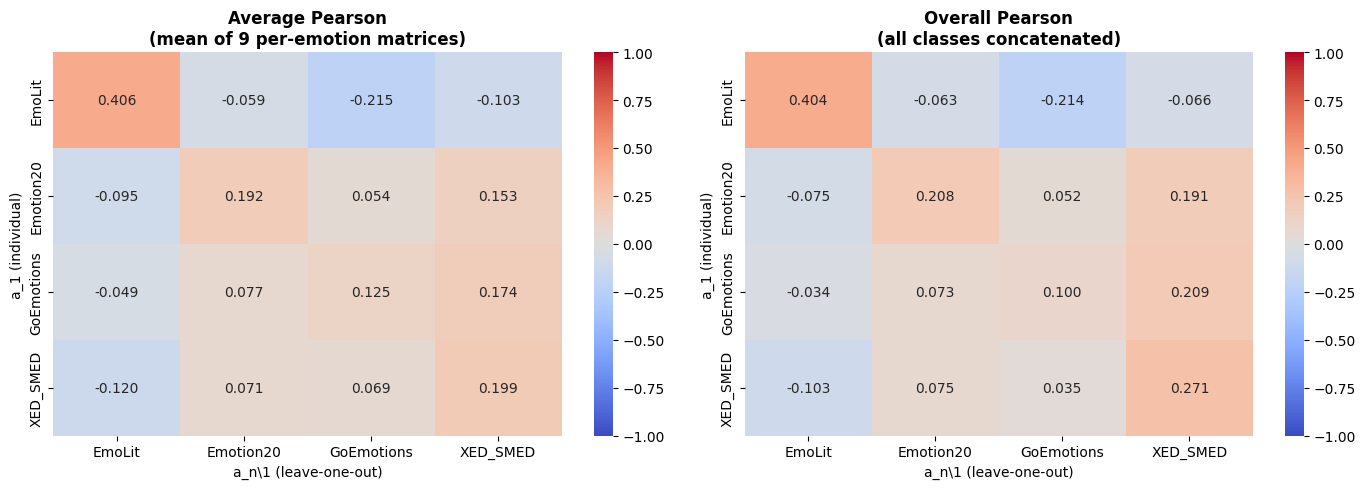

Average Pearson matrix:
            EmoLit  Emotion20  GoEmotions  XED_SMED
EmoLit       0.406     -0.059      -0.215    -0.103
Emotion20   -0.095      0.192       0.054     0.153
GoEmotions  -0.049      0.077       0.125     0.174
XED_SMED    -0.120      0.071       0.069     0.199

Overall Pearson matrix:
            EmoLit  Emotion20  GoEmotions  XED_SMED
EmoLit       0.404     -0.063      -0.214    -0.066
Emotion20   -0.075      0.208       0.052     0.191
GoEmotions  -0.034      0.073       0.100     0.209
XED_SMED    -0.103      0.075       0.035     0.271


In [ ]:
# ============================================================================
# Average Pearson (mean of 9 per-emotion matrices) + Overall Pearson (all classes)
# ============================================================================

# ── 1. Average of the 9 per-emotion Pearson matrices ─────────────────────
avg_pearson = np.mean(
    [D for D in class_diagnostics_pearson.values()], axis=0
)

# ── 2. Overall Pearson: correlate full vectors across ALL classes ─────────
overall_pearson = np.zeros((4, 4))
for i, name_i in enumerate(DATASET_NAMES):
    vec_1_full = np.concatenate([
        aligned_matrices[SINGLE_KEYS[i]][:, c] for c in range(len(ID2LABEL))
    ])
    for j, name_j in enumerate(DATASET_NAMES):
        vec_n1_full = np.concatenate([
            (alpha_n_matrix - aligned_matrices[N1_KEYS[j]])[:, c]
            for c in range(len(ID2LABEL))
        ])
        if np.std(vec_1_full) < 1e-10 or np.std(vec_n1_full) < 1e-10:
            overall_pearson[i, j] = 0.0
        else:
            overall_pearson[i, j], _ = pearsonr(vec_1_full, vec_n1_full)

# ── Plot side by side ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(avg_pearson, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            xticklabels=DATASET_NAMES, yticklabels=DATASET_NAMES, ax=ax1)
ax1.set_title("Average Pearson\n(mean of 9 per-emotion matrices)", fontsize=12, fontweight='bold')
ax1.set_ylabel("a_1 (individual)")
ax1.set_xlabel("a_n\\1 (leave-one-out)")

sns.heatmap(overall_pearson, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            xticklabels=DATASET_NAMES, yticklabels=DATASET_NAMES, ax=ax2)
ax2.set_title("Overall Pearson\n(all classes concatenated)", fontsize=12, fontweight='bold')
ax2.set_ylabel("a_1 (individual)")
ax2.set_xlabel("a_n\\1 (leave-one-out)")

plt.tight_layout()
plt.show()

print("Average Pearson matrix:")
print(pd.DataFrame(avg_pearson, index=DATASET_NAMES, columns=DATASET_NAMES).to_string(float_format="%.3f"))
print("\nOverall Pearson matrix:")
print(pd.DataFrame(overall_pearson, index=DATASET_NAMES, columns=DATASET_NAMES).to_string(float_format="%.3f"))